# 18A — Implied event-timing audit

## Purpose

This notebook is a methodological audit, not a redesign. It evaluates which daily Bloomberg implied-volatility label is the last defensible operational observation before each scheduled announcement. N14–N17 remain frozen and N18 is not modified here.

The precise Bloomberg daily IV snapshot time is unresolved in extracted metadata. Every inferential timing diagnostic and recommendation below is TRAIN-only; TEST observations are not used to select a convention. Any recommendation is an empirically supported operational convention, not confirmation of Bloomberg metadata.


In [1]:
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
if not (ROOT / "CODEWORK").exists():
    ROOT = ROOT.parents[1]
WORK = ROOT / "CODEWORK" / "Linus' Task Re-Do"
DATA = WORK / "Data"
PROCESSED = DATA / "processed"

PRIMARY_FAMILIES = ("FOMC", "US Employment", "US CPI", "BoJ", "JPY National CPI", "JPY GDP")
OFFSETS = (-2, -1, 0, 1)
BOOTSTRAP_REPS = 2_000
BOOTSTRAP_SEED = 18_001
AUDIT_SAVED_OUTPUTS = []  # This audit deliberately creates no external files.

paths = {
    "canonical analysis panel": PROCESSED / "16_empirical_analysis_panel.csv",
    "N18 eventless forecasts": PROCESSED / "18_eventless_forecasts.csv",
    "N18 event occurrences": PROCESSED / "18_event_occurrences.csv",
    "N18 target-specific mapping": PROCESSED / "18_target_specific_event_mapping.csv",
    "N18 event-family mapping": PROCESSED / "18_event_family_mapping.csv",
    "merged event source": DATA / "G10_events_merged_1997-2026.csv",
}
assert all(path.exists() for path in paths.values())

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1 << 20), b""):
            digest.update(block)
    return digest.hexdigest()

CANONICAL_NOTEBOOKS = [
    WORK / "14_empirical_data_audit_and_alignment.ipynb",
    WORK / "15_empirical_variable_construction.ipynb",
    WORK / "16_empirical_gc_tdmi_dependence_structure.ipynb",
    WORK / "17_empirical_parametric_calibration_and_forecasting.ipynb",
    WORK / "18_empirical_eventless_counterfactual_and_weights.ipynb",
    WORK / "19_empirical_nonparametric_causal_structure_and_event_weights.ipynb",
    WORK / "20_empirical_event_weight_api.ipynb",
    WORK / "21_empirical_hidden_event_discovery_and_signal_synthesis.ipynb",
]
CANONICAL_DATA_OUTPUTS = [*paths.values(), DATA / "interim" / "g10_usd_jpy_events_audited.csv", *sorted(PROCESSED.glob("18_*.csv"))]
assert all(path.exists() for path in [*CANONICAL_NOTEBOOKS, *CANONICAL_DATA_OUTPUTS])
hash_targets = [*CANONICAL_NOTEBOOKS, *CANONICAL_DATA_OUTPUTS]
start_hashes = {str(path.resolve()): sha256_file(path) for path in hash_targets}
display(pd.DataFrame({"path": list(start_hashes), "sha256": list(start_hashes.values())}))


,path,sha256
0,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,b30bd370d1875e197ad188e3f0de0b522cfad336987b34...
1,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,06a250b35264c3c07dc3e473375d55b4029c7582492fac...
2,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,71c7399a8864d81fd914ea516d951c2a41692ed051d963...
3,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,e198efac2212d285d8fe192b87e89dda2359f927d5d27e...
4,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,d1814c1a9bc6de8999715bbe87cbefdf0e9b0deb7d953d...
...,...,...
59,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,f241e8b2095502350085ce60a1d1fef60446ccbd4a7f66...
60,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,1bb9f84ac33aee0dc0102d65352818dd2f852b1a540362...
61,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,c4b5d93f588281c095fc3a901fefbe7625186d2f22b63f...
62,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,7d4aaee1fea62944378ae42f28e8be91bad1da45a409d1...


## 18A.0 — Frozen assumptions and data inventory

The canonical model-day, variables, split labels, forecast floors, and N18 eventless background forecasts are read-only inputs. The audit does not write a recommendation into N18 or change any project data.

The TRAIN interval is read from the canonical analysis panel below; it is not hard-coded.


In [2]:
# Read only the columns required for the audit.
panel = pd.read_csv(paths["canonical analysis panel"], parse_dates=["model_day"])
forecasts = pd.read_csv(paths["N18 eventless forecasts"], parse_dates=["model_day", "target_model_day"])
occurrences = pd.read_csv(
    paths["N18 event occurrences"],
    parse_dates=["realised_model_day", "implied_model_day", "event_timestamp_utc", "event_timestamp_ny"],
)
target_mapping = pd.read_csv(
    paths["N18 target-specific mapping"],
    parse_dates=["realised_model_day", "implied_model_day", "event_timestamp_utc", "event_timestamp_ny", "target_model_day"],
)
family_mapping = pd.read_csv(paths["N18 event-family mapping"])
raw_events = pd.read_csv(paths["merged event source"])

panel = panel.sort_values("model_day").reset_index(drop=True)
panel["canonical_index"] = np.arange(len(panel))
train_panel = panel.loc[panel["sample_split"].eq("train")].copy()
train_start, train_end = train_panel["model_day"].min(), train_panel["model_day"].max()
print(f"Canonical TRAIN interval: {train_start.date()} to {train_end.date()} ({len(train_panel):,} observed model days)")

raw_primary = raw_events.merge(
    family_mapping, left_on="event", right_on="raw_event_label", how="inner", validate="many_to_one"
).rename(columns={"mapped_family": "family"})
raw_primary["datetime_utc"] = pd.to_datetime(raw_primary["datetime_utc"], utc=True, format="mixed")
raw_primary["event_timestamp_ny"] = raw_primary["datetime_utc"].dt.tz_convert("America/New_York")

inventory_rows = []
for label, frame, time_col in [
    ("canonical analysis panel", panel, None),
    ("N18 eventless forecasts", forecasts, None),
    ("N18 event occurrences", occurrences, "event_timestamp_utc"),
    ("merged primary event source", raw_primary, "datetime_utc"),
]:
    date_candidates = [c for c in ["model_day", "realised_model_day", "datetime_utc"] if c in frame.columns]
    date_series = pd.to_datetime(frame[date_candidates[0]], errors="coerce") if date_candidates else pd.Series(dtype="datetime64[ns]")
    inventory_rows.append({
        "source": label,
        "rows": len(frame),
        "date_range": f"{date_series.min()} to {date_series.max()}" if len(date_series) else "n/a",
        "relevant_columns": " | ".join(c for c in ["sample_split", "family", "event", "event_timestamp_utc", "datetime_utc", "surprise", "surprise_z", "iv_model_var", "actual", "admissible_background_forecast"] if c in frame.columns),
        "missing_event_time": int(frame[time_col].isna().sum()) if time_col else np.nan,
        "missing_surprise": int(frame["surprise"].isna().sum()) if "surprise" in frame else np.nan,
        "missing_surprise_z": int(frame["surprise_z"].isna().sum()) if "surprise_z" in frame else np.nan,
    })
data_inventory = pd.DataFrame(inventory_rows)
display(data_inventory)
display(Markdown("**Inventory interpretation.** The event-time and surprise fields are reported as extracted. Missing timing metadata is retained as uncertainty rather than filled with assumed release times."))


Canonical TRAIN interval: 2003-05-05 to 2017-03-27 (3,626 observed model days)


,source,rows,date_range,relevant_columns,missing_event_time,missing_surprise,missing_surprise_z
0,canonical analysis panel,6044,2003-05-05 00:00:00 to 2026-07-02 00:00:00,sample_split | iv_model_var,NaN,NaN,NaN
1,N18 eventless forecasts,9752,2003-05-07 00:00:00 to 2026-07-01 00:00:00,sample_split | actual | admissible_background_...,NaN,NaN,NaN
2,N18 event occurrences,1414,2003-05-06 00:00:00 to 2026-06-19 00:00:00,sample_split | family | event_timestamp_utc,0.0,NaN,NaN
3,merged primary event source,6892,1997-01-10 12:00:00+00:00 to 2026-07-01 10:00:...,family | event | datetime_utc | surprise | sur...,0.0,211.0,426.0


**Inventory interpretation.** The event-time and surprise fields are reported as extracted. Missing timing metadata is retained as uncertainty rather than filled with assumed release times.

## 18A.1 — Reconstructing the timing problem

For an announcement on calendar date $D$, this audit distinguishes the announcement date from the canonical model-day label and from the Bloomberg daily IV label. Candidate $D-1$, $D$, and nearby offsets refer to adjacent observed canonical model-day positions, not calendar-day subtraction.

The current N18 implied mapping is read from its target-specific mapping file. Announcement time categories are descriptive only; they do not assert a Bloomberg snapshot time or choose a mapping.


In [3]:
occurrences["event_timestamp_utc"] = pd.to_datetime(occurrences["event_timestamp_utc"], utc=True, format="mixed")
occurrences["event_timestamp_ny"] = occurrences["event_timestamp_utc"].dt.tz_convert("America/New_York")
# The current N18 implied convention is already present in the read-only occurrence export.
occ = occurrences.copy()
occ["announcement_calendar_date"] = occ["event_timestamp_ny"].dt.date
occ["ny_hour"] = occ["event_timestamp_ny"].dt.hour + occ["event_timestamp_ny"].dt.minute / 60
occ["announcement_session"] = np.select(
    [occ["ny_hour"].lt(8), occ["ny_hour"].lt(12), occ["ny_hour"].ge(12)],
    ["Asia hours", "US morning", "US afternoon"],
    default="time unavailable",
)

# Map each event's canonical D to adjacent observed model-day labels.
model_day_by_index = panel.set_index("canonical_index")["model_day"]
model_index = panel.set_index("model_day")["canonical_index"]
occ["D_canonical_index"] = occ["realised_model_day"].map(model_index)
for offset in OFFSETS:
    occ[f"candidate_D{offset:+d}_model_day"] = (occ["D_canonical_index"] + offset).map(model_day_by_index)

timing_summary = (
    occ.loc[occ["family"].isin(PRIMARY_FAMILIES)]
    .groupby("family", as_index=False)
    .agg(
        n_occurrences=("event_id", "size"),
        first_announcement_date=("announcement_calendar_date", "min"),
        last_announcement_date=("announcement_calendar_date", "max"),
        observed_ny_time_range=("event_timestamp_ny", lambda x: f"{x.min()} to {x.max()}"),
        session_categories=("announcement_session", lambda x: " | ".join(sorted(x.dropna().unique()))),
        current_N18_implied_offset=("implied_shift_model_days", lambda x: " | ".join(map(str, sorted(pd.Series(x).dropna().unique())))),
        surprise_z_available=("event_id", "size"),
    )
)
surprise_availability = raw_primary.groupby("family")["surprise_z"].apply(lambda x: int(x.notna().sum())).rename("n_raw_surprise_z").reset_index()
timing_summary = timing_summary.merge(surprise_availability, on="family", how="left")
timing_summary["surprise_z_available"] = timing_summary["n_raw_surprise_z"].gt(0)
display(timing_summary)

timing_occurrence_table = occ.loc[
    occ["family"].isin(PRIMARY_FAMILIES),
    ["family", "announcement_calendar_date", "event_timestamp_utc", "event_timestamp_ny", "announcement_session",
     "realised_model_day", "implied_model_day", "implied_shift_model_days",
     "candidate_D-1_model_day", "candidate_D+0_model_day", "candidate_D+1_model_day"],
].sort_values(["family", "event_timestamp_utc"])
display(timing_occurrence_table.head(24))
display(Markdown("**Timing interpretation.** Source timestamps identify when an announcement occurred where present, but do not identify when Bloomberg sampled the daily IV label. This table therefore describes the timing problem and does not select an offset."))


,family,n_occurrences,first_announcement_date,last_announcement_date,observed_ny_time_range,session_categories,current_N18_implied_offset,surprise_z_available,n_raw_surprise_z
0,BoJ,221,2006-08-11,2026-06-16,2006-08-11 00:17:00-04:00 to 2026-06-16 00:19:...,Asia hours | US afternoon | US morning,0,True,96
1,FOMC,189,2003-05-06,2026-06-17,2003-05-06 15:13:00-04:00 to 2026-06-17 15:00:...,US afternoon | US morning,0,True,211
2,JPY GDP,174,2004-12-07,2026-06-07,2004-12-07 18:50:00-05:00 to 2026-06-07 20:50:...,US afternoon,0,True,970
3,JPY National CPI,277,2003-05-29,2026-06-18,2003-05-29 20:30:08-04:00 to 2026-06-18 20:30:...,US afternoon,0,True,289
4,US CPI,277,2003-05-16,2026-06-10,2003-05-16 09:30:00-04:00 to 2026-06-10 09:30:...,US morning,0,True,3090
5,US Employment,276,2003-06-06,2026-06-05,2003-06-06 09:30:00-04:00 to 2026-06-05 09:30:...,US morning,0,True,1810


,family,announcement_calendar_date,event_timestamp_utc,event_timestamp_ny,announcement_session,realised_model_day,implied_model_day,implied_shift_model_days,candidate_D-1_model_day,candidate_D+0_model_day,candidate_D+1_model_day
0,BoJ,2006-08-11,2006-08-11 04:17:00+00:00,2006-08-11 00:17:00-04:00,Asia hours,2006-08-11,2006-08-11,0,2006-08-10,2006-08-11,2006-08-14
1,BoJ,2006-09-08,2006-09-08 04:37:00+00:00,2006-09-08 00:37:00-04:00,Asia hours,2006-09-08,2006-09-08,0,2006-09-07,2006-09-08,2006-09-11
2,BoJ,2006-10-13,2006-10-13 04:47:00+00:00,2006-10-13 00:47:00-04:00,Asia hours,2006-10-13,2006-10-13,0,2006-10-12,2006-10-13,2006-10-16
3,BoJ,2006-10-30,2006-10-31 03:47:00+00:00,2006-10-30 22:47:00-05:00,US afternoon,2006-10-31,2006-10-31,0,2006-10-30,2006-10-31,2006-11-01
4,BoJ,2006-11-15,2006-11-16 03:24:00+00:00,2006-11-15 22:24:00-05:00,US afternoon,2006-11-16,2006-11-16,0,2006-11-15,2006-11-16,2006-11-17
5,BoJ,2006-12-18,2006-12-19 03:27:00+00:00,2006-12-18 22:27:00-05:00,US afternoon,2006-12-19,2006-12-19,0,2006-12-18,2006-12-19,2006-12-20
6,BoJ,2007-01-17,2007-01-18 03:27:00+00:00,2007-01-17 22:27:00-05:00,US afternoon,2007-01-18,2007-01-18,0,2007-01-17,2007-01-18,2007-01-19
7,BoJ,2007-02-21,2007-02-21 05:20:00+00:00,2007-02-21 00:20:00-05:00,Asia hours,2007-02-21,2007-02-21,0,2007-02-20,2007-02-21,2007-02-22
8,BoJ,2007-03-19,2007-03-20 03:42:00+00:00,2007-03-19 23:42:00-04:00,US afternoon,2007-03-20,2007-03-20,0,2007-03-19,2007-03-20,2007-03-21
9,BoJ,2007-04-09,2007-04-09 04:48:00+00:00,2007-04-09 00:48:00-04:00,Asia hours,2007-04-09,2007-04-09,0,2007-04-06,2007-04-09,2007-04-10


**Timing interpretation.** Source timestamps identify when an announcement occurred where present, but do not identify when Bloomberg sampled the daily IV label. This table therefore describes the timing problem and does not select an offset.

## 18A.2 — Superseded preliminary surprise diagnostic

**This preliminary display is retained only to preserve notebook flow and is not audit evidence.** It pools source observations before the occurrence-level support rule introduced in 18A.5. The authoritative TRAIN-only surprise diagnostic appears in 18A.5, where families with weak raw-surprise support are excluded from timing inference.

$$
\Delta\log I_D = a+b\lvert surprise_{D,z}\rvert+\varepsilon_D.
$$

The corrected diagnostic retains the same asymmetric interpretation: a detectable relationship is only evidence consistent with post-release information, and a null remains inconclusive.


,family,n_usable,beta_abs_surprise_z,robust_se,ci_low,ci_high,p_value,r_squared,spearman_rho,spearman_p
0,US Employment,136,-0.034287,0.086484,-0.203796,0.135222,0.691772,0.000952,-0.095613,0.268172
1,US CPI,148,-0.022415,0.046389,-0.113337,0.068506,0.628946,0.001581,0.112741,0.172480
2,FOMC,99,0.079273,0.037505,0.005763,0.152782,0.034543,0.012784,0.208225,0.038618


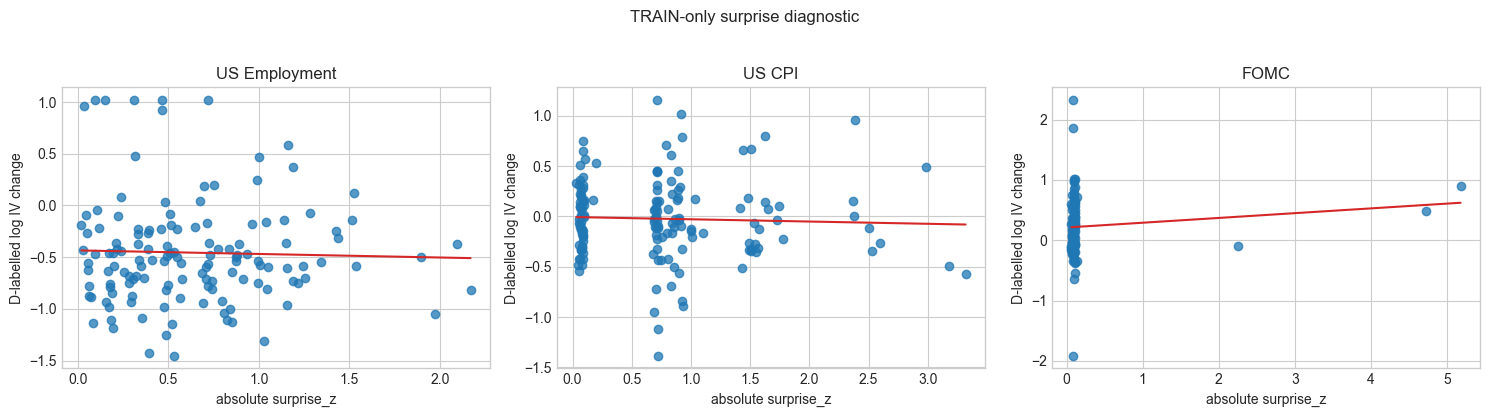

**Surprise interpretation.** Significant relationships, if any, are evidence consistent with a post-release D-labelled quote. Null relationships remain inconclusive because surprise power, IV persistence, and event anticipation can all attenuate this diagnostic.

In [4]:
# Aggregate multiple source rows at a family-time occurrence transparently by maximum absolute available surprise_z.
# This preserves the event source while avoiding an invented single component release for multi-release families.
raw_surprise = (
    raw_primary.groupby(["family", "datetime_utc"], as_index=False)
    .agg(
        surprise_z_abs=("surprise_z", lambda x: x.abs().max()),
        surprise_z_available=("surprise_z", lambda x: x.notna().any()),
        raw_event_labels=("event", lambda x: " | ".join(sorted(set(x)))),
    )
)
occ_surprise = occ.merge(
    raw_surprise, left_on=["family", "event_timestamp_utc"], right_on=["family", "datetime_utc"],
    how="left", validate="one_to_one"
)
iv = panel[["model_day", "sample_split", "iv_model_var"]].copy()
iv["iv_level_change_D"] = iv["iv_model_var"].diff()
iv["iv_log_change_D"] = np.log(iv["iv_model_var"].where(iv["iv_model_var"].gt(0))).diff()
surprise_events = occ_surprise.merge(iv, left_on="realised_model_day", right_on="model_day", how="left", validate="many_to_one")
surprise_events = surprise_events.loc[surprise_events["realised_sample_split"].eq("train")].copy()
assert surprise_events["realised_sample_split"].eq("train").all()

surprise_rows, surprise_samples = [], {}
for family in ["US Employment", "US CPI", "FOMC"]:
    part = surprise_events.loc[
        surprise_events["family"].eq(family)
        & surprise_events["surprise_z_abs"].notna()
        & surprise_events["iv_log_change_D"].notna()
    ].copy()
    surprise_samples[family] = part
    if len(part) < 8:
        surprise_rows.append({"family": family, "n_usable": len(part), "beta_abs_surprise_z": np.nan, "robust_se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan, "r_squared": np.nan, "spearman_rho": np.nan, "spearman_p": np.nan})
        continue
    fit = sm.OLS(part["iv_log_change_D"], sm.add_constant(part["surprise_z_abs"])).fit(cov_type="HC1")
    beta, se, p_value = fit.params["surprise_z_abs"], fit.bse["surprise_z_abs"], fit.pvalues["surprise_z_abs"]
    rho, rho_p = spearmanr(part["iv_log_change_D"].abs(), part["surprise_z_abs"])
    surprise_rows.append({"family": family, "n_usable": len(part), "beta_abs_surprise_z": beta, "robust_se": se, "ci_low": beta - 1.96 * se, "ci_high": beta + 1.96 * se, "p_value": p_value, "r_squared": fit.rsquared, "spearman_rho": rho, "spearman_p": rho_p})
surprise_diagnostic = pd.DataFrame(surprise_rows)
display(surprise_diagnostic)

usable_plot_families = [f for f, d in surprise_samples.items() if len(d) >= 8]
if usable_plot_families:
    fig, axes = plt.subplots(1, len(usable_plot_families), figsize=(5 * len(usable_plot_families), 4), squeeze=False)
    for axis, family in zip(axes.ravel(), usable_plot_families):
        part = surprise_samples[family]
        axis.scatter(part["surprise_z_abs"], part["iv_log_change_D"], alpha=.75)
        fitted = sm.OLS(part["iv_log_change_D"], sm.add_constant(part["surprise_z_abs"])).fit()
        x = np.linspace(part["surprise_z_abs"].min(), part["surprise_z_abs"].max(), 100)
        axis.plot(x, fitted.predict(sm.add_constant(x)), color="tab:red")
        axis.set(title=family, xlabel="absolute surprise_z", ylabel="D-labelled log IV change")
    fig.suptitle("TRAIN-only surprise diagnostic", y=1.03)
    fig.tight_layout()
    plt.show()

post_release_families = set(surprise_diagnostic.loc[surprise_diagnostic["p_value"].lt(.05), "family"])
display(Markdown("**Surprise interpretation.** Significant relationships, if any, are evidence consistent with a post-release D-labelled quote. Null relationships remain inconclusive because surprise power, IV persistence, and event anticipation can all attenuate this diagnostic."))


## 18A.3 — TRAIN-only implied response-weight offset profile

For each occurrence and offset $k\in\{-2,-1,0,+1\}$, the audit reuses N18's admissible eventless background forecast:

$$
\omega^{I}_{D+k}=\frac{I_{D+k}}{F^{I,adm}_{D+k}}.
$$

No forecast is recalibrated and no floor is changed. The profile is descriptive: a weight above one is not automatically more correct or more economically attractive than a weight below one.


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_40184\467017801.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  offset_weights["equation_eligible"].fillna(False)


,family,offset,usable_n,mean_omega_I,median_omega_I,q05,q25,q75,q95,pct_below_1,pct_above_1
0,BoJ,-2,109,1.261313,0.912448,0.485899,0.698563,1.268673,3.673202,0.614679,0.385321
1,BoJ,-1,113,2.078302,1.152232,0.523401,0.779186,1.972672,4.133535,0.407080,0.592920
2,BoJ,0,115,1.006671,0.814778,0.332523,0.608697,1.187851,2.063388,0.660870,0.339130
3,BoJ,1,116,0.938889,0.814293,0.356720,0.604423,1.073584,1.787020,0.689655,0.310345
4,FOMC,-2,78,1.615405,1.113315,0.522950,0.819570,1.694945,4.329389,0.410256,0.589744
5,FOMC,-1,78,1.691371,0.926238,0.516536,0.700933,1.180672,1.889182,0.589744,0.410256
6,FOMC,0,78,1.330470,1.046936,0.656086,0.844588,1.557150,2.289846,0.410256,0.589744
7,FOMC,1,79,1.303578,0.872121,0.470030,0.643341,1.344798,2.448087,0.594937,0.405063
8,JPY GDP,-2,60,1.488224,0.972859,0.530632,0.743244,1.412113,3.366185,0.516667,0.483333
9,JPY GDP,-1,62,1.104111,0.867849,0.418850,0.636147,1.105187,2.834198,0.661290,0.338710


,reference,usable_n,mean_omega_I,median_omega_I,q05,q25,q75,q95,pct_below_1,pct_above_1
0,TRAIN ordinary implied days under current N18 ...,1704,1.266754,0.954749,0.443388,0.714329,1.346951,2.792274,0.540493,0.459507


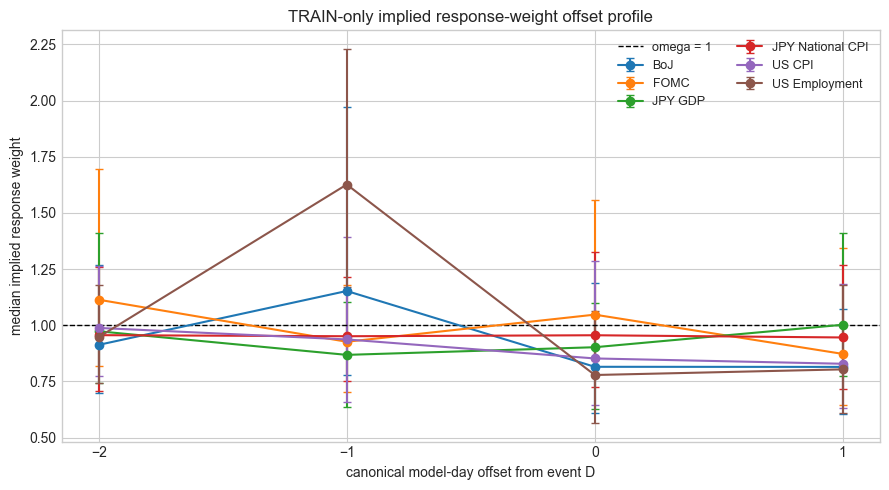

**Offset-profile interpretation.** The plot describes the distribution of frozen-background weights at nearby observed model days. It is not a timing-optimisation rule and does not select the offset with the largest median.

In [5]:
# Expand TRAIN occurrences over canonical offset positions and merge frozen N18 implied forecasts.
train_occ = occ.loc[occ["realised_sample_split"].eq("train") & occ["family"].isin(PRIMARY_FAMILIES)].copy()
train_occ = train_occ.loc[train_occ["D_canonical_index"].notna()].copy()
offset_rows = []
for offset in OFFSETS:
    part = train_occ[["event_id", "family", "realised_model_day", "D_canonical_index"]].copy()
    part["offset"] = offset
    part["target_canonical_index"] = part["D_canonical_index"] + offset
    part["target_model_day"] = part["target_canonical_index"].map(model_day_by_index)
    offset_rows.append(part)
offset_events = pd.concat(offset_rows, ignore_index=True)

i_forecasts = forecasts.loc[
    forecasts["target"].eq("I") & forecasts["sample_split"].eq("train"),
    ["target_model_day", "sample_split", "actual", "admissible_background_forecast", "equation_eligible", "background_positive", "is_target_event_day"],
].copy()
offset_weights = offset_events.merge(i_forecasts, on="target_model_day", how="left", validate="many_to_one")
offset_weights["weight_defined"] = (
    offset_weights["equation_eligible"].fillna(False)
    & offset_weights["actual"].gt(0)
    & offset_weights["admissible_background_forecast"].gt(0)
)
offset_weights["omega_I_adm"] = np.where(
    offset_weights["weight_defined"],
    offset_weights["actual"] / offset_weights["admissible_background_forecast"],
    np.nan,
)
assert offset_weights.loc[offset_weights["weight_defined"], "omega_I_adm"].gt(0).all()
assert offset_weights.loc[offset_weights["weight_defined"], "sample_split"].eq("train").all()

def distribution_summary(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values):
        return {"usable_n": 0, "mean_omega_I": np.nan, "median_omega_I": np.nan, "q05": np.nan, "q25": np.nan, "q75": np.nan, "q95": np.nan, "pct_below_1": np.nan, "pct_above_1": np.nan}
    return {"usable_n": len(values), "mean_omega_I": values.mean(), "median_omega_I": np.median(values), "q05": np.quantile(values, .05), "q25": np.quantile(values, .25), "q75": np.quantile(values, .75), "q95": np.quantile(values, .95), "pct_below_1": (values < 1).mean(), "pct_above_1": (values > 1).mean()}

profile_rows = []
for (family, offset), group in offset_weights.groupby(["family", "offset"], sort=True):
    profile_rows.append({"family": family, "offset": offset, **distribution_summary(group.loc[group["weight_defined"], "omega_I_adm"])})
implied_offset_profile = pd.DataFrame(profile_rows).sort_values(["family", "offset"])
display(implied_offset_profile)

ordinary_train = i_forecasts.loc[~i_forecasts["is_target_event_day"].fillna(False)].copy()
ordinary_train["omega_I_adm"] = np.where(
    ordinary_train["equation_eligible"].fillna(False) & ordinary_train["actual"].gt(0) & ordinary_train["admissible_background_forecast"].gt(0),
    ordinary_train["actual"] / ordinary_train["admissible_background_forecast"], np.nan
)
ordinary_implied_reference = pd.DataFrame([{"reference": "TRAIN ordinary implied days under current N18 event-day exclusion", **distribution_summary(ordinary_train["omega_I_adm"])}])
display(ordinary_implied_reference)

fig, ax = plt.subplots(figsize=(9, 5))
for family, group in implied_offset_profile.groupby("family", sort=False):
    x = group["offset"].to_numpy()
    y = group["median_omega_I"].to_numpy()
    lower = y - group["q25"].to_numpy()
    upper = group["q75"].to_numpy() - y
    ax.errorbar(x, y, yerr=[lower, upper], marker="o", capsize=3, label=family)
ax.axhline(1, color="black", linewidth=1, linestyle="--", label="omega = 1")
ax.set(xlabel="canonical model-day offset from event D", ylabel="median implied response weight", xticks=list(OFFSETS), title="TRAIN-only implied response-weight offset profile")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()
display(Markdown("**Offset-profile interpretation.** The plot describes the distribution of frozen-background weights at nearby observed model days. It is not a timing-optimisation rule and does not select the offset with the largest median."))


## 18A.4 — DESCRIPTIVE CURRENT-BACKGROUND COMPARISON: $D$ versus $D-1$

The paired comparison uses only TRAIN occurrences with both defined weights. Its bootstrap interval is descriptive uncertainty for

$$
\operatorname{median}(\log\omega^I_D-\log\omega^I_{D-1}).
$$

It does not test or choose a mapping.


In [6]:
rng = np.random.default_rng(BOOTSTRAP_SEED)
paired_source = offset_weights.loc[
    offset_weights["offset"].isin([-1, 0]) & offset_weights["weight_defined"],
    ["event_id", "family", "offset", "omega_I_adm"],
].copy()
paired_wide = paired_source.pivot(index=["event_id", "family"], columns="offset", values="omega_I_adm").reset_index()

comparison_rows = []
for family in PRIMARY_FAMILIES:
    profile_family = offset_weights.loc[offset_weights["family"].eq(family) & offset_weights["weight_defined"]]
    d_values = profile_family.loc[profile_family["offset"].eq(0), "omega_I_adm"].to_numpy()
    dm1_values = profile_family.loc[profile_family["offset"].eq(-1), "omega_I_adm"].to_numpy()
    paired = paired_wide.loc[paired_wide["family"].eq(family)].dropna(subset=[-1, 0])
    delta = np.log(paired[0].to_numpy()) - np.log(paired[-1].to_numpy())
    if len(delta) >= 5:
        boot = np.array([np.median(rng.choice(delta, size=len(delta), replace=True)) for _ in range(BOOTSTRAP_REPS)])
        ci_low, ci_high = np.quantile(boot, [.025, .975])
    else:
        ci_low = ci_high = np.nan
    comparison_rows.append({
        "family": family, "n_D": len(d_values), "median_D": np.median(d_values) if len(d_values) else np.nan,
        "iqr_D": np.subtract(*np.quantile(d_values, [.75, .25])) if len(d_values) else np.nan,
        "pct_D_below_1": (d_values < 1).mean() if len(d_values) else np.nan, "pct_D_above_1": (d_values > 1).mean() if len(d_values) else np.nan,
        "n_D_minus_1": len(dm1_values), "median_D_minus_1": np.median(dm1_values) if len(dm1_values) else np.nan,
        "iqr_D_minus_1": np.subtract(*np.quantile(dm1_values, [.75, .25])) if len(dm1_values) else np.nan,
        "pct_D_minus_1_below_1": (dm1_values < 1).mean() if len(dm1_values) else np.nan, "pct_D_minus_1_above_1": (dm1_values > 1).mean() if len(dm1_values) else np.nan,
        "n_paired": len(delta), "median_log_omega_D_minus_D_minus_1": np.median(delta) if len(delta) else np.nan,
        "bootstrap_ci_low": ci_low, "bootstrap_ci_high": ci_high,
    })
direct_D_vs_Dminus1 = pd.DataFrame(comparison_rows)
display(direct_D_vs_Dminus1)
display(Markdown("**Paired-comparison interpretation.** Differences quantify how the frozen N18 implied response changes between adjacent labels. They do not establish the unobserved Bloomberg sampling time and are not used to maximise event weights."))


,family,n_D,median_D,iqr_D,pct_D_below_1,pct_D_above_1,n_D_minus_1,median_D_minus_1,iqr_D_minus_1,pct_D_minus_1_below_1,pct_D_minus_1_above_1,n_paired,median_log_omega_D_minus_D_minus_1,bootstrap_ci_low,bootstrap_ci_high
0,FOMC,78,1.046936,0.712563,0.410256,0.589744,78,0.926238,0.479739,0.589744,0.410256,78,0.195924,0.064521,0.435475
1,US Employment,101,0.778214,0.499011,0.712871,0.287129,99,1.626190,1.060149,0.131313,0.868687,99,-0.717898,-0.836027,-0.475990
2,US CPI,99,0.851938,0.641316,0.616162,0.383838,96,0.936577,0.733515,0.583333,0.416667,96,-0.054276,-0.225187,0.132931
3,BoJ,115,0.814778,0.579154,0.660870,0.339130,113,1.152232,1.193485,0.407080,0.592920,111,-0.354620,-0.619472,-0.035220
4,JPY National CPI,112,0.955181,0.600796,0.544643,0.455357,113,0.950826,0.459433,0.557522,0.442478,111,0.043822,-0.129661,0.179068
5,JPY GDP,62,0.901893,0.473632,0.580645,0.419355,62,0.867849,0.469040,0.661290,0.338710,62,-0.003081,-0.190249,0.136830


**Paired-comparison interpretation.** Differences quantify how the frozen N18 implied response changes between adjacent labels. They do not establish the unobserved Bloomberg sampling time and are not used to maximise event weights.

## 18A.5 — Preliminary material superseded by pass 1

The preliminary recommendation rule is withdrawn. The corrected pass-1 source, surprise and timestamp audit below supplies the authoritative interim evidence; no operational mapping is selected in this notebook pass.

The existing profiles and paired comparison remain descriptive current-background evidence only.


In [7]:
# The preliminary recommendation rule was removed in pass 1.
# The corrected currency-clean evidence and interim table below make no production mapping.
display(Markdown("**Preliminary recommendation withdrawn.** This audit retains the descriptive current-background comparisons, but no timing mapping is selected before the candidate-specific TRAIN refits."))


**Preliminary recommendation withdrawn.** This audit retains the descriptive current-background comparisons, but no timing mapping is selected before the candidate-specific TRAIN refits.

## Inference safeguards

- Surprise evidence is asymmetric: a detected relationship is consistent with post-release pricing; a null is not proof of pre-release timing.
- Event weights are not a timing optimisation criterion.
- TEST observations do not enter regressions, bootstrap comparisons, or mapping decisions.
- Bloomberg snapshot metadata remain unknown; no clock time is asserted.
- N21's $R_t\leftrightarrow I_{t-1}$ pairing is an information-availability construction and does not mathematically determine N18's known-event mapping.


In [8]:
# Superseded by the corrected pass-1 closure at the end of this notebook.
# No production timing recommendation is made in this pass.


## 18A.5 — TRAIN-only source support and timestamp audit

Raw-source fields are joined to canonical N18 occurrences by family and timestamp, then restricted to the realised TRAIN split. Support is therefore measured at the occurrence level rather than by pooling heterogeneous component-surprise magnitudes. A family is **ADEQUATE** when it has at least 20 TRAIN occurrences with non-zero raw surprise on at least half of its TRAIN occurrences; it is **LIMITED** when at least one occurrence has a non-zero raw surprise; otherwise it has **INSUFFICIENT_RAW_SURPRISE_SUPPORT**. Surprise-z is descriptive Bloomberg metadata and cannot elevate weak raw-surprise support. Exact Bloomberg IV snapshot timing remains unknown.

In [9]:
# Read the frozen production floor from the existing audit input; do not redefine it.
FORECAST_FLOORS = {"I": float(forecasts.loc[forecasts.target.eq("I"), "forecast_floor"].iloc[0])}
assert FORECAST_FLOORS["I"] == 0.0015767239436135

In [10]:
audited = pd.read_csv(DATA / "interim" / "g10_usd_jpy_events_audited.csv")
audited["event_datetime_utc"] = pd.to_datetime(audited["event_datetime_utc"], utc=True, format="mixed")
raw = audited.merge(family_mapping, left_on="event", right_on="raw_event_label", how="inner", validate="many_to_one").rename(columns={"mapped_family": "family"})
currency_by_family = {"FOMC": "USD", "US Employment": "USD", "US CPI": "USD", "BoJ": "JPY", "JPY National CPI": "JPY", "JPY GDP": "JPY"}
raw["required_currency"] = raw["family"].map(currency_by_family)
raw["currency_valid"] = raw["ccy"].eq(raw["required_currency"])
assert raw.loc[raw["family"].isin(["FOMC", "US Employment", "US CPI"]) & raw["currency_valid"], "ccy"].eq("USD").all()
assert raw.loc[raw["family"].isin(["BoJ", "JPY National CPI", "JPY GDP"]) & raw["currency_valid"], "ccy"].eq("JPY").all()
raw = raw.loc[raw["currency_valid"]].copy()
train_source_occurrences = occ.loc[occ["family"].isin(PRIMARY_FAMILIES) & occ["realised_sample_split"].eq("train"), ["event_id", "family", "event_timestamp_utc", "event_timestamp_ny", "realised_model_day", "realised_sample_split"]].copy()
train_source_occurrences["event_timestamp_utc"] = pd.to_datetime(train_source_occurrences["event_timestamp_utc"], utc=True, format="mixed")
raw_train = raw.merge(train_source_occurrences[["event_id", "family", "event_timestamp_utc"]], left_on=["family", "event_datetime_utc"], right_on=["family", "event_timestamp_utc"], how="inner", validate="many_to_one")
occurrence_support = train_source_occurrences.merge(raw_train.groupby("event_id", as_index=False).agg(any_raw_surprise=("surprise", lambda x: x.notna().any()), any_nonzero_raw_surprise=("surprise", lambda x: (x.dropna().ne(0)).any()), any_surprise_z=("surprise_z", lambda x: x.notna().any()), component_event_labels=("event", lambda x: " | ".join(sorted(set(x)))), n_component_event_labels=("event", "nunique")), on="event_id", how="left", validate="one_to_one")
for column in ["any_raw_surprise", "any_nonzero_raw_surprise", "any_surprise_z"]: occurrence_support[column] = occurrence_support[column].fillna(False).astype(bool)
occurrence_support["n_component_event_labels"] = occurrence_support["n_component_event_labels"].fillna(0).astype(int)
support_rows = []
for family, part in occurrence_support.groupby("family", sort=False):
    nonzero_n = int(part["any_nonzero_raw_surprise"].sum())
    fraction_nonzero = float(part["any_nonzero_raw_surprise"].mean()) if len(part) else np.nan
    status = "ADEQUATE" if len(part) >= 20 and nonzero_n >= 20 and fraction_nonzero >= .5 else ("LIMITED" if nonzero_n else "INSUFFICIENT_RAW_SURPRISE_SUPPORT")
    support_rows.append({"family": family, "train_occurrences": len(part), "occurrences_with_raw_surprise": int(part["any_raw_surprise"].sum()), "occurrences_with_nonzero_raw_surprise": nonzero_n, "fraction_occurrences_with_nonzero_raw_surprise": fraction_nonzero, "occurrences_with_surprise_z": int(part["any_surprise_z"].sum()), "number_of_component_event_labels": int(raw_train.loc[raw_train["family"].eq(family), "event"].nunique()), "surprise_support_status": status})
surprise_support = pd.DataFrame(support_rows).set_index("family").reindex(PRIMARY_FAMILIES).reset_index()
component_surprise_support = raw_train.groupby(["family", "event"], as_index=False).agg(train_source_rows=("event_id", "size"), occurrences=("event_id", "nunique"), raw_surprise_available=("surprise", lambda x: int(x.notna().sum())), raw_surprise_nonzero=("surprise", lambda x: int(x.dropna().ne(0).sum())), surprise_z_available=("surprise_z", lambda x: int(x.notna().sum())))
display(surprise_support)
display(component_surprise_support)
occurrence_support["source_timestamp_utc"] = occurrence_support["event_timestamp_utc"]
occurrence_support["ny_timestamp"] = occurrence_support["source_timestamp_utc"].dt.tz_convert("America/New_York")
occurrence_support["source_clock"] = occurrence_support["source_timestamp_utc"].dt.strftime("%H:%M UTC")
occurrence_support["ny_clock"] = occurrence_support["ny_timestamp"].dt.strftime("%H:%M NY")
def coarse_category(hours):
    values = set(hours.dropna())
    categories = {"ASIA_OVERNIGHT" if h < 8 else "US_MORNING" if h < 12 else "US_AFTERNOON" for h in values}
    return next(iter(categories)) if len(categories) == 1 else "MIXED_OR_AMBIGUOUS"
timestamp_reliability = occurrence_support.groupby("family", as_index=False).agg(train_occurrences=("event_id", "size"), unique_canonical_timestamps=("event_timestamp_utc", "nunique"), observed_source_clock_times=("source_clock", lambda x: " | ".join(sorted(x.dropna().unique())),), observed_ny_clock_times=("ny_clock", lambda x: " | ".join(sorted(x.dropna().unique())),), coarse_announcement_timing=("ny_timestamp", lambda x: coarse_category(x.dt.hour)))
timestamp_reliability["timestamp_reliability"] = "RELIABLE_COARSE"
timestamp_reliability["timestamp_reason"] = "TRAIN occurrence clocks exhibit source/DST variation; exact Bloomberg IV snapshot timing is unresolved."
timestamp_clock_audit = occurrence_support.assign(year=occurrence_support["ny_timestamp"].dt.year).groupby(["family", "year", "source_clock", "ny_clock"], dropna=False).size().rename("n_occurrences").reset_index()
display(timestamp_reliability)
display(timestamp_clock_audit)
display(Markdown("**TRAIN occurrence interpretation.** Support and timestamp summaries now use only canonical N18 TRAIN occurrences. Exact UTC-to-New-York conversion is preserved for the source event timestamp, while DST/source-clock shifts prevent any assertion about the Bloomberg daily IV sampling clock."))

,family,train_occurrences,occurrences_with_raw_surprise,occurrences_with_nonzero_raw_surprise,fraction_occurrences_with_nonzero_raw_surprise,occurrences_with_surprise_z,number_of_component_event_labels,surprise_support_status
0,FOMC,114,112,3,0.026316,112,1,LIMITED
1,US Employment,166,166,157,0.945783,166,2,ADEQUATE
2,US CPI,167,167,107,0.640719,167,1,ADEQUATE
3,BoJ,146,86,4,0.027397,78,1,LIMITED
4,JPY National CPI,165,165,86,0.521212,165,1,ADEQUATE
5,JPY GDP,99,98,89,0.898990,90,3,ADEQUATE


,family,event,train_source_rows,occurrences,raw_surprise_available,raw_surprise_nonzero,surprise_z_available
0,BoJ,BOJ Target Rate,146,146,86,4,78
1,FOMC,FOMC Rate Decision (Upper Bound),114,114,112,3,112
2,JPY GDP,GDP Annualized SA QoQ,21,21,21,20,20
3,JPY GDP,GDP Deflator YoY,13,13,13,9,13
4,JPY GDP,GDP SA QoQ,95,95,94,81,86
5,JPY National CPI,Natl CPI YoY,165,165,165,86,165
6,US CPI,CPI MoM,167,167,167,107,167
7,US Employment,Change in Nonfarm Payrolls,138,138,138,138,138
8,US Employment,Unemployment Rate,29,29,29,20,29


,family,train_occurrences,unique_canonical_timestamps,observed_source_clock_times,observed_ny_clock_times,coarse_announcement_timing,timestamp_reliability,timestamp_reason
0,BoJ,146,146,02:37 UTC | 02:45 UTC | 02:49 UTC | 02:51 UTC ...,00:00 NY | 00:01 NY | 00:03 NY | 00:04 NY | 00...,MIXED_OR_AMBIGUOUS,RELIABLE_COARSE,TRAIN occurrence clocks exhibit source/DST var...
1,FOMC,114,114,12:00 UTC | 13:20 UTC | 16:30 UTC | 17:30 UTC ...,08:00 NY | 08:20 NY | 12:30 NY | 13:30 NY | 14...,MIXED_OR_AMBIGUOUS,RELIABLE_COARSE,TRAIN occurrence clocks exhibit source/DST var...
2,JPY GDP,99,99,00:50 UTC | 23:50 UTC,18:50 NY | 19:50 NY | 20:50 NY,US_AFTERNOON,RELIABLE_COARSE,TRAIN occurrence clocks exhibit source/DST var...
3,JPY National CPI,165,165,00:30 UTC | 23:30 UTC,18:30 NY | 19:30 NY | 20:30 NY,US_AFTERNOON,RELIABLE_COARSE,TRAIN occurrence clocks exhibit source/DST var...
4,US CPI,167,167,12:30 UTC | 13:30 UTC,08:30 NY | 09:30 NY,US_MORNING,RELIABLE_COARSE,TRAIN occurrence clocks exhibit source/DST var...
5,US Employment,166,166,12:30 UTC | 13:30 UTC | 14:30 UTC,08:30 NY | 09:30 NY,US_MORNING,RELIABLE_COARSE,TRAIN occurrence clocks exhibit source/DST var...


,family,year,source_clock,ny_clock,n_occurrences
0,BoJ,2006,03:24 UTC,22:24 NY,1
1,BoJ,2006,03:27 UTC,22:27 NY,1
2,BoJ,2006,03:47 UTC,22:47 NY,1
3,BoJ,2006,04:17 UTC,00:17 NY,1
4,BoJ,2006,04:37 UTC,00:37 NY,1
...,...,...,...,...,...
330,US Employment,2015,13:30 UTC,09:30 NY,7
331,US Employment,2016,12:30 UTC,08:30 NY,1
332,US Employment,2016,13:30 UTC,08:30 NY,4
333,US Employment,2016,13:30 UTC,09:30 NY,7


**TRAIN occurrence interpretation.** Support and timestamp summaries now use only canonical N18 TRAIN occurrences. Exact UTC-to-New-York conversion is preserved for the source event timestamp, while DST/source-clock shifts prevent any assertion about the Bloomberg daily IV sampling clock.

In [11]:
# TRAIN-only occurrence-level surprise diagnostic; no timing mapping is selected here.
train_iv = panel[["model_day", "sample_split", "iv_model_var"]].copy()
train_iv["dlogI"] = np.log(train_iv["iv_model_var"].where(train_iv["iv_model_var"].gt(0))).diff()
train_surprise_z = raw_train.groupby("event_id", as_index=False).agg(abs_surprise_z=("surprise_z", lambda x: x.abs().max()))
surprise_events = occurrence_support.merge(train_surprise_z, on="event_id", how="left", validate="one_to_one").merge(train_iv, left_on="realised_model_day", right_on="model_day", how="left", validate="many_to_one")
assert surprise_events["realised_sample_split"].eq("train").all() and surprise_events["sample_split"].eq("train").all()
regression_rows = []
for family in PRIMARY_FAMILIES:
    status = surprise_support.loc[surprise_support["family"].eq(family), "surprise_support_status"].iloc[0]
    part = surprise_events.loc[surprise_events["family"].eq(family) & surprise_events["abs_surprise_z"].notna() & surprise_events["dlogI"].notna()].copy()
    if status == "ADEQUATE" and len(part) >= 8:
        fit = sm.OLS(part["dlogI"], sm.add_constant(part["abs_surprise_z"])).fit(cov_type="HC1")
        coefficient, robust_se = fit.params.iloc[1], fit.bse.iloc[1]
        rho, rho_p = spearmanr(part["dlogI"].abs(), part["abs_surprise_z"])
        evidence = "SUPPORTS_DATE_D_POST_RELEASE" if fit.pvalues.iloc[1] < .05 else "NO_DETECTABLE_RESPONSE"
        regression_rows.append({"family": family, "n": len(part), "coefficient_b": coefficient, "robust_se": robust_se, "ci_low": coefficient - 1.96 * robust_se, "ci_high": coefficient + 1.96 * robust_se, "p_value": fit.pvalues.iloc[1], "r_squared": fit.rsquared, "spearman_rho": rho, "spearman_p": rho_p, "timing_evidence_usable": True, "timing_evidence_reason": "adequate TRAIN occurrence-level raw-surprise support", "surprise_timing_evidence": evidence})
    else:
        regression_rows.append({"family": family, "n": len(part), "coefficient_b": np.nan, "robust_se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan, "r_squared": np.nan, "spearman_rho": np.nan, "spearman_p": np.nan, "timing_evidence_usable": False, "timing_evidence_reason": status, "surprise_timing_evidence": "INSUFFICIENT_SUPPORT"})
corrected_surprise_regression = pd.DataFrame(regression_rows)
display(corrected_surprise_regression)
old = implied_offset_profile.loc[implied_offset_profile["offset"].isin([-1, 0]), ["family", "offset", "median_omega_I"]].pivot(index="family", columns="offset", values="median_omega_I").rename(columns={-1: "median_omega_Dm1_descriptive", 0: "median_omega_D_descriptive"})
pair = direct_D_vs_Dminus1.set_index("family")[["median_log_omega_D_minus_D_minus_1", "bootstrap_ci_low", "bootstrap_ci_high"]].rename(columns={"median_log_omega_D_minus_D_minus_1": "paired_logweight_difference", "bootstrap_ci_low": "paired_difference_ci_low", "bootstrap_ci_high": "paired_difference_ci_high"})
interim_evidence_table = pd.DataFrame({"event_family": PRIMARY_FAMILIES, "currency": [currency_by_family[f] for f in PRIMARY_FAMILIES]})
for column in surprise_support.columns.drop("family"): interim_evidence_table[column] = interim_evidence_table["event_family"].map(surprise_support.set_index("family")[column])
for column in ["timestamp_reliability", "coarse_announcement_timing"]: interim_evidence_table[column] = interim_evidence_table["event_family"].map(timestamp_reliability.set_index("family")[column])
interim_evidence_table["surprise_timing_evidence"] = interim_evidence_table["event_family"].map(corrected_surprise_regression.set_index("family")["surprise_timing_evidence"])
for column in old.columns: interim_evidence_table[column] = interim_evidence_table["event_family"].map(old[column])
for column in pair.columns: interim_evidence_table[column] = interim_evidence_table["event_family"].map(pair[column])
interim_evidence_table["interim_status"] = "NEEDS_CANDIDATE_REFIT"
interim_evidence_table["reason"] = "No production mapping: only TRAIN occurrence-level support and descriptive current-background evidence are available at this stage."
display(interim_evidence_table)
display(Markdown("**Pass-1 conclusion.** FOMC and BoJ remain unusable for surprise timing inference when support is measured on canonical TRAIN occurrences. Null usable-family regressions are inconclusive, and no production timing mapping is selected."))

,family,n,coefficient_b,robust_se,ci_low,ci_high,p_value,r_squared,spearman_rho,spearman_p,timing_evidence_usable,timing_evidence_reason,surprise_timing_evidence
0,FOMC,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,LIMITED,INSUFFICIENT_SUPPORT
1,US Employment,136,-0.036329,0.087373,-0.207580,0.134923,0.677566,0.000991,-0.117631,0.172607,True,adequate TRAIN occurrence-level raw-surprise s...,NO_DETECTABLE_RESPONSE
2,US CPI,148,-0.022415,0.046389,-0.113337,0.068506,0.628946,0.001581,0.112741,0.172480,True,adequate TRAIN occurrence-level raw-surprise s...,NO_DETECTABLE_RESPONSE
3,BoJ,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,LIMITED,INSUFFICIENT_SUPPORT
4,JPY National CPI,135,-0.045594,0.070646,-0.184060,0.092873,0.518681,0.002225,0.010358,0.905095,True,adequate TRAIN occurrence-level raw-surprise s...,NO_DETECTABLE_RESPONSE
5,JPY GDP,87,0.035780,0.060398,-0.082600,0.154159,0.553582,0.003585,-0.017970,0.868782,True,adequate TRAIN occurrence-level raw-surprise s...,NO_DETECTABLE_RESPONSE


,event_family,currency,train_occurrences,occurrences_with_raw_surprise,occurrences_with_nonzero_raw_surprise,fraction_occurrences_with_nonzero_raw_surprise,occurrences_with_surprise_z,number_of_component_event_labels,surprise_support_status,timestamp_reliability,coarse_announcement_timing,surprise_timing_evidence,median_omega_Dm1_descriptive,median_omega_D_descriptive,paired_logweight_difference,paired_difference_ci_low,paired_difference_ci_high,interim_status,reason
0,FOMC,USD,114,112,3,0.026316,112,1,LIMITED,RELIABLE_COARSE,MIXED_OR_AMBIGUOUS,INSUFFICIENT_SUPPORT,0.926238,1.046936,0.195924,0.064521,0.435475,NEEDS_CANDIDATE_REFIT,No production mapping: only TRAIN occurrence-l...
1,US Employment,USD,166,166,157,0.945783,166,2,ADEQUATE,RELIABLE_COARSE,US_MORNING,NO_DETECTABLE_RESPONSE,1.626190,0.778214,-0.717898,-0.836027,-0.475990,NEEDS_CANDIDATE_REFIT,No production mapping: only TRAIN occurrence-l...
2,US CPI,USD,167,167,107,0.640719,167,1,ADEQUATE,RELIABLE_COARSE,US_MORNING,NO_DETECTABLE_RESPONSE,0.936577,0.851938,-0.054276,-0.225187,0.132931,NEEDS_CANDIDATE_REFIT,No production mapping: only TRAIN occurrence-l...
3,BoJ,JPY,146,86,4,0.027397,78,1,LIMITED,RELIABLE_COARSE,MIXED_OR_AMBIGUOUS,INSUFFICIENT_SUPPORT,1.152232,0.814778,-0.354620,-0.619472,-0.035220,NEEDS_CANDIDATE_REFIT,No production mapping: only TRAIN occurrence-l...
4,JPY National CPI,JPY,165,165,86,0.521212,165,1,ADEQUATE,RELIABLE_COARSE,US_AFTERNOON,NO_DETECTABLE_RESPONSE,0.950826,0.955181,0.043822,-0.129661,0.179068,NEEDS_CANDIDATE_REFIT,No production mapping: only TRAIN occurrence-l...
5,JPY GDP,JPY,99,98,89,0.898990,90,3,ADEQUATE,RELIABLE_COARSE,US_AFTERNOON,NO_DETECTABLE_RESPONSE,0.867849,0.901893,-0.003081,-0.190249,0.136830,NEEDS_CANDIDATE_REFIT,No production mapping: only TRAIN occurrence-l...


**Pass-1 conclusion.** FOMC and BoJ remain unusable for surprise timing inference when support is measured on canonical TRAIN occurrences. Null usable-family regressions are inconclusive, and no production timing mapping is selected.

## 18A.6 — Candidate-specific eventless timing refit

This is a **ONE-FAMILY-AT-A-TIME CANDIDATE-OFFSET AUDIT**. For each focal family, candidate 0 masks the focal D target and candidate -1 masks the immediately preceding observed canonical model-day target. The other five families retain their current N18 implied target mapping in both constructions. The full lagged design is constructed before either candidate target mask is applied; target rows alone are excluded from the TRAIN calibration.

In [12]:
# Exact frozen N18 implied equation reconstructed in this audit only.
EPSILON_I = 0.0015767239436135
refit_panel = panel[["model_day", "sample_split", "squared_return", "realised_variance_ann_252", "iv_model_var"]].copy()
refit_panel["Q"] = pd.to_numeric(refit_panel["squared_return"], errors="coerce")
refit_panel["R"] = pd.to_numeric(refit_panel["realised_variance_ann_252"], errors="coerce")
refit_panel["I"] = pd.to_numeric(refit_panel["iv_model_var"], errors="coerce")
for state in ["Q", "R", "I"]:
    for lag in range(1, 13): refit_panel[f"{state}_lag{lag}"] = refit_panel[state].shift(lag)
I_REFIT_FEATURES = [f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)]
refit_panel["I_base_eligible"] = np.isfinite(refit_panel[["I", *I_REFIT_FEATURES]]).all(axis=1)
refit_lag_snapshot = refit_panel[["model_day", *I_REFIT_FEATURES]].copy()
assert refit_panel["model_day"].equals(panel["model_day"]) and len(I_REFIT_FEATURES) == 36
assert int((refit_panel["sample_split"].eq("train") & refit_panel["I_base_eligible"]).sum()) == 2226
candidate_train_occurrences = occ.loc[occ["family"].isin(PRIMARY_FAMILIES) & occ["realised_sample_split"].eq("train"), ["event_id", "family", "realised_model_day", "D_canonical_index", "implied_shift_model_days"]].copy()
candidate_train_occurrences["current_N18_offset"] = pd.to_numeric(candidate_train_occurrences["implied_shift_model_days"], errors="coerce").fillna(0).astype(int)
assert candidate_train_occurrences["event_id"].is_unique and candidate_train_occurrences["D_canonical_index"].notna().all()
candidate_rows, candidate_masks, candidate_weight_parts = [], [], []
for focal_family in PRIMARY_FAMILIES:
    for candidate_offset in [0, -1]:
        assigned = candidate_train_occurrences.copy()
        assigned["assigned_offset"] = np.where(assigned["family"].eq(focal_family), candidate_offset, assigned["current_N18_offset"])
        assigned["target_canonical_index"] = assigned["D_canonical_index"] + assigned["assigned_offset"]
        assigned["target_model_day"] = assigned["target_canonical_index"].map(model_day_by_index)
        assert assigned["target_model_day"].notna().all()
        mask_days = pd.Index(assigned["target_model_day"].unique())
        other_target_days = set(assigned.loc[assigned["family"].ne(focal_family), "target_model_day"])
        focal = assigned.loc[assigned["family"].eq(focal_family)].copy()
        focal["candidate_offset"] = candidate_offset
        focal["overlaps_other_family_target"] = focal["target_model_day"].isin(other_target_days)
        calibration = refit_panel.loc[refit_panel["sample_split"].eq("train") & refit_panel["I_base_eligible"] & ~refit_panel["model_day"].isin(mask_days)].copy()
        assert not calibration["model_day"].isin(mask_days).any()
        assert refit_panel[["model_day", *I_REFIT_FEATURES]].equals(refit_lag_snapshot)
        fit = sm.OLS(calibration["I"], sm.add_constant(calibration[I_REFIT_FEATURES], has_constant="add")).fit()
        evaluated = focal.merge(refit_panel[["model_day", "I", "I_base_eligible", *I_REFIT_FEATURES]], left_on="target_model_day", right_on="model_day", how="left", validate="one_to_one")
        evaluated["raw_background_forecast"] = fit.predict(sm.add_constant(evaluated[I_REFIT_FEATURES], has_constant="add"))
        evaluated["admissible_background_forecast"] = np.maximum(evaluated["raw_background_forecast"], EPSILON_I)
        evaluated["floor_activated"] = evaluated["raw_background_forecast"].lt(EPSILON_I)
        evaluated["weight_defined"] = evaluated["I_base_eligible"].fillna(False) & evaluated["I"].gt(0) & np.isfinite(evaluated["admissible_background_forecast"])
        evaluated["omega_I_candidate"] = np.where(evaluated["weight_defined"], evaluated["I"] / evaluated["admissible_background_forecast"], np.nan)
        valid = evaluated.loc[evaluated["weight_defined"]].copy()
        values = valid["omega_I_candidate"].to_numpy(dtype=float)
        candidate_rows.append({"family": focal_family, "candidate_offset": candidate_offset, "train_occurrences": len(focal), "usable_event_forecasts": len(valid), "eventless_calibration_n": len(calibration), "number_of_masked_train_targets": len(mask_days), "overlap_target_count": int(focal["overlaps_other_family_target"].sum()), "raw_forecast_floor_activation_count": int(evaluated["floor_activated"].sum()), "raw_forecast_floor_activation_rate": float(evaluated["floor_activated"].mean()), "median_actual_I": float(np.median(valid["I"])) if len(valid) else np.nan, "median_raw_background_forecast": float(np.median(valid["raw_background_forecast"])) if len(valid) else np.nan, "median_admissible_background_forecast": float(np.median(valid["admissible_background_forecast"])) if len(valid) else np.nan, "mean_omega_I": float(np.mean(values)) if len(values) else np.nan, "median_omega_I": float(np.median(values)) if len(values) else np.nan, "q05_omega_I": float(np.quantile(values, .05)) if len(values) else np.nan, "q25_omega_I": float(np.quantile(values, .25)) if len(values) else np.nan, "q75_omega_I": float(np.quantile(values, .75)) if len(values) else np.nan, "q95_omega_I": float(np.quantile(values, .95)) if len(values) else np.nan, "pct_omega_below_1": float(np.mean(values < 1)) if len(values) else np.nan, "pct_omega_above_1": float(np.mean(values > 1)) if len(values) else np.nan})
        candidate_masks.append({"family": focal_family, "candidate_offset": candidate_offset, "other_family_mask_signature": tuple(sorted(assigned.loc[assigned["family"].ne(focal_family), "target_model_day"].dt.strftime("%Y-%m-%d").unique())), "focal_target_index": tuple(focal["target_canonical_index"]), "focal_D_index": tuple(focal["D_canonical_index"])})
        candidate_weight_parts.append(evaluated[["event_id", "family", "candidate_offset", "realised_model_day", "target_model_day", "target_canonical_index", "I", "raw_background_forecast", "admissible_background_forecast", "floor_activated", "weight_defined", "omega_I_candidate"]].copy())
candidate_weights = pd.concat(candidate_weight_parts, ignore_index=True)
candidate_refit_summary = pd.DataFrame(candidate_rows).sort_values(["family", "candidate_offset"])
candidate_mask_audit = pd.DataFrame(candidate_masks)
display(candidate_refit_summary)
paired_rows = []
for family in PRIMARY_FAMILIES:
    paired = candidate_weights.loc[candidate_weights["family"].eq(family) & candidate_weights["weight_defined"]].pivot(index="event_id", columns="candidate_offset", values="omega_I_candidate").dropna(subset=[-1, 0])
    delta = np.log(paired[0].to_numpy()) - np.log(paired[-1].to_numpy())
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    boot = np.median(rng.choice(delta, size=(BOOTSTRAP_REPS, len(delta)), replace=True), axis=1) if len(delta) >= 2 else np.array([])
    paired_rows.append({"family": family, "n_paired": len(delta), "median_Delta_candidate": float(np.median(delta)) if len(delta) else np.nan, "q25": float(np.quantile(delta, .25)) if len(delta) else np.nan, "q75": float(np.quantile(delta, .75)) if len(delta) else np.nan, "bootstrap_95_CI_low": float(np.quantile(boot, .025)) if len(boot) else np.nan, "bootstrap_95_CI_high": float(np.quantile(boot, .975)) if len(boot) else np.nan})
candidate_paired_comparison = pd.DataFrame(paired_rows)
display(candidate_paired_comparison)
candidate_medians = candidate_refit_summary.pivot(index="family", columns="candidate_offset", values="median_omega_I").rename(columns={-1: "median_omega_candidate_minus_1_refit", 0: "median_omega_candidate_0_refit"})
refit_comparison = old.join(candidate_medians).join(pair).join(candidate_paired_comparison.set_index("family"))
refit_comparison["background_refit_materiality"] = np.where((np.sign(refit_comparison["paired_logweight_difference"]) != np.sign(refit_comparison["median_Delta_candidate"])) | (np.abs(refit_comparison["paired_logweight_difference"] - refit_comparison["median_Delta_candidate"]) >= .10), "MATERIALLY_CHANGED", "QUALITATIVELY_SIMILAR")
display(refit_comparison[["median_omega_Dm1_descriptive", "median_omega_D_descriptive", "median_omega_candidate_minus_1_refit", "median_omega_candidate_0_refit", "paired_logweight_difference", "median_Delta_candidate", "bootstrap_95_CI_low", "bootstrap_95_CI_high", "background_refit_materiality"]])


,family,candidate_offset,train_occurrences,usable_event_forecasts,eventless_calibration_n,number_of_masked_train_targets,overlap_target_count,raw_forecast_floor_activation_count,raw_forecast_floor_activation_rate,median_actual_I,median_raw_background_forecast,median_admissible_background_forecast,mean_omega_I,median_omega_I,q05_omega_I,q25_omega_I,q75_omega_I,q95_omega_I,pct_omega_below_1,pct_omega_above_1
7,BoJ,-1,146,113,1691,818,24,2,0.013699,0.016050,0.012670,0.012670,2.031361,1.220323,0.506155,0.823105,2.264067,4.527992,0.380531,0.619469
6,BoJ,0,146,115,1704,803,39,0,0.000000,0.013112,0.014806,0.014806,1.006671,0.814778,0.332523,0.608697,1.187851,2.063388,0.660870,0.339130
1,FOMC,-1,114,78,1705,802,18,2,0.017544,0.011515,0.013669,0.013669,1.844609,0.906152,0.488760,0.687136,1.183149,1.948356,0.589744,0.410256
0,FOMC,0,114,78,1704,803,17,0,0.000000,0.014636,0.014665,0.014665,1.330470,1.046936,0.656086,0.844588,1.557150,2.289846,0.410256,0.589744
11,JPY GDP,-1,99,62,1710,792,20,1,0.010101,0.010802,0.012376,0.012376,1.110657,0.850973,0.429657,0.635465,1.129085,2.873560,0.661290,0.338710
10,JPY GDP,0,99,62,1704,803,9,1,0.010101,0.010148,0.011772,0.011772,1.096713,0.901893,0.392416,0.625436,1.099068,2.626144,0.580645,0.419355
9,JPY National CPI,-1,165,113,1700,805,10,1,0.006061,0.010939,0.009471,0.009471,1.298962,1.005141,0.486111,0.763286,1.386216,2.698482,0.495575,0.504425
8,JPY National CPI,0,165,112,1704,803,12,1,0.006061,0.011660,0.011287,0.011287,1.089110,0.955181,0.398436,0.725825,1.326621,2.020701,0.544643,0.455357
5,US CPI,-1,167,96,1702,802,23,4,0.023952,0.011197,0.012061,0.012061,1.274137,0.928988,0.436715,0.633589,1.404378,3.058963,0.583333,0.416667
4,US CPI,0,167,99,1704,803,22,2,0.011976,0.011713,0.012744,0.012744,1.149852,0.851938,0.488692,0.644291,1.285607,3.037314,0.616162,0.383838


,family,n_paired,median_Delta_candidate,q25,q75,bootstrap_95_CI_low,bootstrap_95_CI_high
0,FOMC,78,0.292952,-0.169546,0.599524,0.076921,0.428200
1,US Employment,99,-0.761935,-1.189820,-0.215395,-0.884615,-0.583956
2,US CPI,96,-0.019612,-0.453760,0.478519,-0.242797,0.161264
3,BoJ,111,-0.348051,-1.080642,0.275119,-0.601084,-0.075002
4,JPY National CPI,111,-0.103835,-0.435078,0.448628,-0.178243,0.138523
5,JPY GDP,62,-0.019457,-0.330858,0.266938,-0.214900,0.161682


,median_omega_Dm1_descriptive,median_omega_D_descriptive,median_omega_candidate_minus_1_refit,median_omega_candidate_0_refit,paired_logweight_difference,median_Delta_candidate,bootstrap_95_CI_low,bootstrap_95_CI_high,background_refit_materiality
family,,,,,,,,,
BoJ,1.152232,0.814778,1.220323,0.814778,-0.354620,-0.348051,-0.601084,-0.075002,QUALITATIVELY_SIMILAR
FOMC,0.926238,1.046936,0.906152,1.046936,0.195924,0.292952,0.076921,0.428200,QUALITATIVELY_SIMILAR
JPY GDP,0.867849,0.901893,0.850973,0.901893,-0.003081,-0.019457,-0.214900,0.161682,QUALITATIVELY_SIMILAR
JPY National CPI,0.950826,0.955181,1.005141,0.955181,0.043822,-0.103835,-0.178243,0.138523,MATERIALLY_CHANGED
US CPI,0.936577,0.851938,0.928988,0.851938,-0.054276,-0.019612,-0.242797,0.161264,QUALITATIVELY_SIMILAR
US Employment,1.626190,0.778214,1.718957,0.778214,-0.717898,-0.761935,-0.884615,-0.583956,QUALITATIVELY_SIMILAR


## 18A.7 — Final audit evidence for manual mapping review

The candidate comparison is descriptive: a larger response weight is not a claim that an offset is correct. The review status below summarizes whether the paired candidate response distributions are clearly separated after each offset receives its own TRAIN eventless background. It is not a production mapping.

In [13]:
final_audit_evidence = pd.DataFrame({"event_family": PRIMARY_FAMILIES})
for source, columns in [(timestamp_reliability.set_index("family"), ["coarse_announcement_timing", "timestamp_reliability"]), (surprise_support.set_index("family"), ["train_occurrences", "surprise_support_status"]), (corrected_surprise_regression.set_index("family"), ["surprise_timing_evidence"]), (candidate_medians, ["median_omega_candidate_minus_1_refit", "median_omega_candidate_0_refit"]), (candidate_paired_comparison.set_index("family"), ["median_Delta_candidate", "bootstrap_95_CI_low", "bootstrap_95_CI_high"]), (refit_comparison, ["background_refit_materiality"])]:
    for column in columns: final_audit_evidence[column] = final_audit_evidence["event_family"].map(source[column])
final_audit_evidence = final_audit_evidence.rename(columns={"median_Delta_candidate": "candidate_log_difference", "bootstrap_95_CI_low": "candidate_log_difference_ci_low", "bootstrap_95_CI_high": "candidate_log_difference_ci_high"})
final_audit_evidence["candidate_refit_pattern"] = np.select([final_audit_evidence["candidate_log_difference_ci_low"].gt(0), final_audit_evidence["candidate_log_difference_ci_high"].lt(0)], ["D_RESPONSE_HIGHER", "D_MINUS_1_RESPONSE_HIGHER"], default="NO_CLEAR_SEPARATION")
final_audit_evidence["current_N18_offset"] = final_audit_evidence["event_family"].map(candidate_train_occurrences.groupby("family")["current_N18_offset"].first())
final_audit_evidence["mapping_review_status"] = np.select([final_audit_evidence["candidate_refit_pattern"].eq("D_MINUS_1_RESPONSE_HIGHER"), final_audit_evidence["candidate_refit_pattern"].eq("D_RESPONSE_HIGHER"), final_audit_evidence["surprise_support_status"].ne("ADEQUATE")], ["EVIDENCE_FAVOURS_D_MINUS_1", "EVIDENCE_FAVOURS_D", "AMBIGUOUS_REQUIRES_REVIEW"], default="NO_CLEAR_SEPARATION")
final_audit_evidence["reason"] = np.where(final_audit_evidence["mapping_review_status"].eq("NO_CLEAR_SEPARATION"), "Candidate-specific paired interval crosses zero; manual review remains required.", np.where(final_audit_evidence["mapping_review_status"].eq("AMBIGUOUS_REQUIRES_REVIEW"), "No clear paired separation and TRAIN raw-surprise support is limited.", "Paired candidate interval is descriptively separated; no production mapping is implied."))
display(final_audit_evidence)
clear_families = ", ".join(final_audit_evidence.loc[final_audit_evidence["candidate_refit_pattern"].ne("NO_CLEAR_SEPARATION"), "event_family"]) or "none"
ambiguous_families = ", ".join(final_audit_evidence.loc[final_audit_evidence["candidate_refit_pattern"].eq("NO_CLEAR_SEPARATION"), "event_family"]) or "none"
material_families = ", ".join(refit_comparison.index[refit_comparison["background_refit_materiality"].eq("MATERIALLY_CHANGED")]) or "none"
display(Markdown(f"**Candidate-refit interpretation.** TRAIN occurrence-level support determines regression usability; FOMC and BoJ remain unsupported when raw surprise is weak. Clearly separated candidate patterns: {clear_families}. No-clear-separation families: {ambiguous_families}. Candidate-specific refitting materially changes the original descriptive log-difference for: {material_families}. N18 remains unchanged because this evidence table is for manual review and does not identify Bloomberg's unobserved daily-IV snapshot time."))
display(Markdown("**Candidate-refit status.** The final robustness checks below retain these unchanged candidate-specific results and add no new candidate offset."))

,event_family,coarse_announcement_timing,timestamp_reliability,train_occurrences,surprise_support_status,surprise_timing_evidence,median_omega_candidate_minus_1_refit,median_omega_candidate_0_refit,candidate_log_difference,candidate_log_difference_ci_low,candidate_log_difference_ci_high,background_refit_materiality,candidate_refit_pattern,current_N18_offset,mapping_review_status,reason
0,FOMC,MIXED_OR_AMBIGUOUS,RELIABLE_COARSE,114,LIMITED,INSUFFICIENT_SUPPORT,0.906152,1.046936,0.292952,0.076921,0.428200,QUALITATIVELY_SIMILAR,D_RESPONSE_HIGHER,0,EVIDENCE_FAVOURS_D,Paired candidate interval is descriptively sep...
1,US Employment,US_MORNING,RELIABLE_COARSE,166,ADEQUATE,NO_DETECTABLE_RESPONSE,1.718957,0.778214,-0.761935,-0.884615,-0.583956,QUALITATIVELY_SIMILAR,D_MINUS_1_RESPONSE_HIGHER,0,EVIDENCE_FAVOURS_D_MINUS_1,Paired candidate interval is descriptively sep...
2,US CPI,US_MORNING,RELIABLE_COARSE,167,ADEQUATE,NO_DETECTABLE_RESPONSE,0.928988,0.851938,-0.019612,-0.242797,0.161264,QUALITATIVELY_SIMILAR,NO_CLEAR_SEPARATION,0,NO_CLEAR_SEPARATION,Candidate-specific paired interval crosses zer...
3,BoJ,MIXED_OR_AMBIGUOUS,RELIABLE_COARSE,146,LIMITED,INSUFFICIENT_SUPPORT,1.220323,0.814778,-0.348051,-0.601084,-0.075002,QUALITATIVELY_SIMILAR,D_MINUS_1_RESPONSE_HIGHER,0,EVIDENCE_FAVOURS_D_MINUS_1,Paired candidate interval is descriptively sep...
4,JPY National CPI,US_AFTERNOON,RELIABLE_COARSE,165,ADEQUATE,NO_DETECTABLE_RESPONSE,1.005141,0.955181,-0.103835,-0.178243,0.138523,MATERIALLY_CHANGED,NO_CLEAR_SEPARATION,0,NO_CLEAR_SEPARATION,Candidate-specific paired interval crosses zer...
5,JPY GDP,US_AFTERNOON,RELIABLE_COARSE,99,ADEQUATE,NO_DETECTABLE_RESPONSE,0.850973,0.901893,-0.019457,-0.214900,0.161682,QUALITATIVELY_SIMILAR,NO_CLEAR_SEPARATION,0,NO_CLEAR_SEPARATION,Candidate-specific paired interval crosses zer...


**Candidate-refit interpretation.** TRAIN occurrence-level support determines regression usability; FOMC and BoJ remain unsupported when raw surprise is weak. Clearly separated candidate patterns: FOMC, US Employment, BoJ. No-clear-separation families: US CPI, JPY National CPI, JPY GDP. Candidate-specific refitting materially changes the original descriptive log-difference for: JPY National CPI. N18 remains unchanged because this evidence table is for manual review and does not identify Bloomberg's unobserved daily-IV snapshot time.

**Candidate-refit status.** The final robustness checks below retain these unchanged candidate-specific results and add no new candidate offset.

## 18A.8 — Final robustness checks for manual timing review

These checks do not alter the candidate-specific refit. They test its FOMC composition, Employment weekday confounding, and sensitivity to the documented one-hour timestamp uncertainty. All mapping-selection evidence remains restricted to canonical TRAIN occurrences.

In [14]:
# FOMC source-component and afternoon-only robustness, using existing candidate-refit weights.
fomc_source = raw_train.loc[raw_train["family"].eq("FOMC")].copy()
fomc_source["ny_timestamp"] = fomc_source["event_datetime_utc"].dt.tz_convert("America/New_York")
fomc_source["ny_clock"] = fomc_source["ny_timestamp"].dt.strftime("%H:%M")
fomc_source["ny_clock_minutes"] = fomc_source["ny_timestamp"].dt.hour * 60 + fomc_source["ny_timestamp"].dt.minute
fomc_component_clock_audit = fomc_source.groupby("event", as_index=False).agg(n_occurrences=("event_id", "nunique"), unique_clock_times=("ny_clock", lambda x: " | ".join(sorted(x.unique())),), median_clock_minutes=("ny_clock_minutes", "median"), morning_n=("ny_timestamp", lambda x: int(x.dt.hour.lt(12).sum())), afternoon_n=("ny_timestamp", lambda x: int(x.dt.hour.ge(12).sum())))
fomc_component_clock_audit["median_clock_time"] = fomc_component_clock_audit["median_clock_minutes"].map(lambda x: f"{int(x // 60):02d}:{int(x % 60):02d}" if pd.notna(x) else "")
fomc_component_clock_audit["notes"] = np.where(fomc_component_clock_audit["event"].str.contains("FOMC Rate Decision", case=False, na=False), "Policy-decision label; afternoon records are the genuine scheduled policy subset.", "Non-policy or unmatched source label.")
display(fomc_component_clock_audit[["event", "n_occurrences", "unique_clock_times", "median_clock_time", "morning_n", "afternoon_n", "notes"]].rename(columns={"event": "raw_event_label"}))
fomc_occurrence_timestamp_audit = fomc_source[["event_id", "event", "event_datetime_utc", "ny_timestamp", "ny_clock"]].sort_values("event_datetime_utc").rename(columns={"event": "raw_event_label", "event_datetime_utc": "original_source_timestamp_utc", "ny_timestamp": "converted_new_york_timestamp"})
display(fomc_occurrence_timestamp_audit)
fomc_afternoon_ids = set(fomc_source.loc[fomc_source["event"].str.contains("FOMC Rate Decision", case=False, na=False) & fomc_source["ny_timestamp"].dt.hour.ge(12), "event_id"])
fomc_afternoon = candidate_weights.loc[candidate_weights["family"].eq("FOMC") & candidate_weights["event_id"].isin(fomc_afternoon_ids) & candidate_weights["weight_defined"]].pivot(index="event_id", columns="candidate_offset", values="omega_I_candidate").dropna(subset=[-1, 0])
fomc_afternoon_delta = np.log(fomc_afternoon[0].to_numpy()) - np.log(fomc_afternoon[-1].to_numpy())
fomc_rng = np.random.default_rng(BOOTSTRAP_SEED)
fomc_boot = np.median(fomc_rng.choice(fomc_afternoon_delta, size=(BOOTSTRAP_REPS, len(fomc_afternoon_delta)), replace=True), axis=1) if len(fomc_afternoon_delta) >= 2 else np.array([])
fomc_afternoon_summary = pd.DataFrame([{"subset": "genuine_scheduled_afternoon_policy", "n_paired": len(fomc_afternoon_delta), "median_omega_candidate_minus1": float(np.median(fomc_afternoon[-1])) if len(fomc_afternoon_delta) else np.nan, "median_omega_candidate_0": float(np.median(fomc_afternoon[0])) if len(fomc_afternoon_delta) else np.nan, "median_log_difference": float(np.median(fomc_afternoon_delta)) if len(fomc_afternoon_delta) else np.nan, "q25": float(np.quantile(fomc_afternoon_delta, .25)) if len(fomc_afternoon_delta) else np.nan, "q75": float(np.quantile(fomc_afternoon_delta, .75)) if len(fomc_afternoon_delta) else np.nan, "bootstrap_95_CI_low": float(np.quantile(fomc_boot, .025)) if len(fomc_boot) else np.nan, "bootstrap_95_CI_high": float(np.quantile(fomc_boot, .975)) if len(fomc_boot) else np.nan}])
fomc_afternoon_result = "SUPPORTS_D" if len(fomc_afternoon_delta) >= 8 and fomc_afternoon_summary.loc[0, "bootstrap_95_CI_low"] > 0 else ("SUPPORTS_D_MINUS_1" if len(fomc_afternoon_delta) >= 8 and fomc_afternoon_summary.loc[0, "bootstrap_95_CI_high"] < 0 else ("INSUFFICIENT_SAMPLE" if len(fomc_afternoon_delta) < 8 else "NO_CLEAR_SEPARATION"))
fomc_afternoon_summary["fomc_afternoon_result"] = fomc_afternoon_result
display(fomc_afternoon_summary)

# Matched ordinary weekday placebo for US Employment, using previous observed model-day rows.
weekday_panel = panel[["model_day", "sample_split", "iv_ann_var", "iv_model_var"]].copy()
weekday_panel["previous_model_day"] = weekday_panel["model_day"].shift(1)
weekday_panel["previous_split"] = weekday_panel["sample_split"].shift(1)
for column in ["iv_ann_var", "iv_model_var"]: weekday_panel[f"previous_{column}"] = weekday_panel[column].shift(1)
weekday_panel["weekday_transition"] = weekday_panel["previous_model_day"].dt.day_name() + " -> " + weekday_panel["model_day"].dt.day_name()
weekday_panel["Delta_raw"] = np.log(weekday_panel["iv_ann_var"].where(weekday_panel["iv_ann_var"].gt(0))) - np.log(weekday_panel["previous_iv_ann_var"].where(weekday_panel["previous_iv_ann_var"].gt(0)))
weekday_panel["Delta_model"] = np.log(weekday_panel["iv_model_var"].where(weekday_panel["iv_model_var"].gt(0))) - np.log(weekday_panel["previous_iv_model_var"].where(weekday_panel["previous_iv_model_var"].gt(0)))
employment_days = candidate_train_occurrences.loc[candidate_train_occurrences["family"].eq("US Employment"), "realised_model_day"]
employment_transitions = weekday_panel.loc[weekday_panel["model_day"].isin(employment_days) & weekday_panel["sample_split"].eq("train") & weekday_panel["previous_split"].eq("train")].copy()
employment_weekday_composition = employment_transitions.groupby("weekday_transition", as_index=False).size().rename(columns={"size": "n"})
dominant_transition = employment_weekday_composition.sort_values("n", ascending=False).iloc[0]["weekday_transition"]
primary_train_target_days = set(candidate_train_occurrences["realised_model_day"])
ordinary_placebo = weekday_panel.loc[weekday_panel["sample_split"].eq("train") & weekday_panel["previous_split"].eq("train") & weekday_panel["weekday_transition"].eq(dominant_transition) & ~weekday_panel["model_day"].isin(primary_train_target_days) & ~weekday_panel["previous_model_day"].isin(primary_train_target_days)].copy()
display(employment_weekday_composition)
placebo_rows = []
for measure in ["Delta_raw", "Delta_model"]:
    event_values = employment_transitions[measure].dropna().to_numpy(dtype=float)
    ordinary_values = ordinary_placebo[measure].dropna().to_numpy(dtype=float)
    placebo_rng = np.random.default_rng(BOOTSTRAP_SEED)
    boot_difference = np.median(placebo_rng.choice(event_values, size=(BOOTSTRAP_REPS, len(event_values)), replace=True), axis=1) - np.median(placebo_rng.choice(ordinary_values, size=(BOOTSTRAP_REPS, len(ordinary_values)), replace=True), axis=1)
    pooled = pd.concat([pd.DataFrame({measure: event_values, "Employment": 1}), pd.DataFrame({measure: ordinary_values, "Employment": 0})], ignore_index=True)
    placebo_fit = sm.OLS(pooled[measure], sm.add_constant(pooled["Employment"])).fit(cov_type="HC1")
    beta, robust_se = placebo_fit.params["Employment"], placebo_fit.bse["Employment"]
    placebo_rows.append({"measure": measure, "Employment_n": len(event_values), "ordinary_placebo_n": len(ordinary_values), "Employment_mean": float(np.mean(event_values)), "Employment_median": float(np.median(event_values)), "ordinary_mean": float(np.mean(ordinary_values)), "ordinary_median": float(np.median(ordinary_values)), "difference_in_medians": float(np.median(event_values) - np.median(ordinary_values)), "bootstrap_95_CI_low": float(np.quantile(boot_difference, .025)), "bootstrap_95_CI_high": float(np.quantile(boot_difference, .975)), "Employment_coefficient_b": beta, "robust_se": robust_se, "coefficient_ci_low": beta - 1.96 * robust_se, "coefficient_ci_high": beta + 1.96 * robust_se, "p_value": placebo_fit.pvalues["Employment"]})
employment_weekday_placebo = pd.DataFrame(placebo_rows)
display(employment_weekday_placebo)
placebo_index = employment_weekday_placebo.set_index("measure")
raw_survives = placebo_index.loc["Delta_raw", "difference_in_medians"] < 0 and placebo_index.loc["Delta_raw", "bootstrap_95_CI_high"] < 0
model_survives = placebo_index.loc["Delta_model", "difference_in_medians"] < 0 and placebo_index.loc["Delta_model", "bootstrap_95_CI_high"] < 0
employment_weekday_placebo_result = "SURVIVES_WEEKDAY_PLACEBO" if raw_survives and model_survives else ("PARTLY_EXPLAINED_BY_WEEKDAY" if raw_survives or model_survives else "CONSISTENT_WITH_WEEKDAY_EFFECT")
display(Markdown(f"**Employment weekday placebo.** Dominant canonical TRAIN transition: {dominant_transition}. Result: **{employment_weekday_placebo_result}**."))


,raw_event_label,n_occurrences,unique_clock_times,median_clock_time,morning_n,afternoon_n,notes
0,FOMC Rate Decision (Upper Bound),114,08:00 | 08:20 | 12:30 | 13:30 | 14:00 | 14:14 ...,14:15,2,112,Policy-decision label; afternoon records are t...


,event_id,raw_event_label,original_source_timestamp_utc,converted_new_york_timestamp,ny_clock
0,FOMC__20030506,FOMC Rate Decision (Upper Bound),2003-05-06 19:13:00+00:00,2003-05-06 15:13:00-04:00,15:13
5,FOMC__20030625,FOMC Rate Decision (Upper Bound),2003-06-25 19:15:00+00:00,2003-06-25 15:15:00-04:00,15:15
11,FOMC__20030812,FOMC Rate Decision (Upper Bound),2003-08-12 19:15:00+00:00,2003-08-12 15:15:00-04:00,15:15
16,FOMC__20030916,FOMC Rate Decision (Upper Bound),2003-09-16 19:19:00+00:00,2003-09-16 15:19:00-04:00,15:19
20,FOMC__20031028,FOMC Rate Decision (Upper Bound),2003-10-28 19:15:00+00:00,2003-10-28 14:15:00-05:00,14:15
...,...,...,...,...,...
857,FOMC__20160921,FOMC Rate Decision (Upper Bound),2016-09-21 19:00:00+00:00,2016-09-21 15:00:00-04:00,15:00
863,FOMC__20161102,FOMC Rate Decision (Upper Bound),2016-11-02 18:00:00+00:00,2016-11-02 14:00:00-04:00,14:00
870,FOMC__20161214,FOMC Rate Decision (Upper Bound),2016-12-14 19:00:00+00:00,2016-12-14 14:00:00-05:00,14:00
878,FOMC__20170201,FOMC Rate Decision (Upper Bound),2017-02-01 19:00:00+00:00,2017-02-01 14:00:00-05:00,14:00


,subset,n_paired,median_omega_candidate_minus1,median_omega_candidate_0,median_log_difference,q25,q75,bootstrap_95_CI_low,bootstrap_95_CI_high,fomc_afternoon_result
0,genuine_scheduled_afternoon_policy,76,0.891348,1.046936,0.29852,-0.164203,0.605754,0.075663,0.483286,SUPPORTS_D


,weekday_transition,n
0,Monday -> Tuesday,1
1,Thursday -> Friday,160
2,Wednesday -> Thursday,5


,measure,Employment_n,ordinary_placebo_n,Employment_mean,Employment_median,ordinary_mean,ordinary_median,difference_in_medians,bootstrap_95_CI_low,bootstrap_95_CI_high,Employment_coefficient_b,robust_se,coefficient_ci_low,coefficient_ci_high,p_value
0,Delta_raw,136,207,-1.423542,-1.502351,-0.882701,-0.949991,-0.552360,-0.691000,-0.454477,-0.540841,0.055424,-0.649472,-0.432210,1.701153e-22
1,Delta_model,136,207,-0.455826,-0.532282,0.134701,0.067411,-0.599693,-0.717533,-0.489906,-0.590526,0.054232,-0.696822,-0.484231,1.302973e-27


**Employment weekday placebo.** Dominant canonical TRAIN transition: Thursday -> Friday. Result: **SURVIVES_WEEKDAY_PLACEBO**.

In [15]:
# ±1-hour timestamp perturbation and post-event exposure are descriptive invariance checks.
sessions = pd.DataFrame({"model_day": panel["model_day"]})
sessions["session_open_ny"] = (sessions["model_day"] - pd.Timedelta(days=1) + pd.Timedelta(hours=17)).dt.tz_localize("America/New_York")
sessions["session_close_ny"] = (sessions["model_day"] + pd.Timedelta(hours=17)).dt.tz_localize("America/New_York")
sessions["session_open_utc"] = sessions["session_open_ny"].dt.tz_convert("UTC")
sessions["session_close_utc"] = sessions["session_close_ny"].dt.tz_convert("UTC")
def assign_model_day(timestamp_series):
    probe = pd.DataFrame({"row_id": np.arange(len(timestamp_series)), "timestamp": pd.to_datetime(timestamp_series, utc=True).to_numpy()}).sort_values("timestamp")
    mapped = pd.merge_asof(probe, sessions[["model_day", "session_open_utc", "session_close_utc"]].sort_values("session_open_utc"), left_on="timestamp", right_on="session_open_utc", direction="backward")
    mapped["assigned_model_day"] = mapped["model_day"].where(mapped["timestamp"].lt(mapped["session_close_utc"]))
    return mapped.set_index("row_id")["assigned_model_day"].sort_index()
dst_rows = train_source_occurrences[["event_id", "family", "event_timestamp_utc", "realised_model_day"]].copy()
dst_rows["minus1h_model_day"] = assign_model_day(dst_rows["event_timestamp_utc"] - pd.Timedelta(hours=1)).to_numpy()
dst_rows["original_model_day"] = assign_model_day(dst_rows["event_timestamp_utc"]).to_numpy()
dst_rows["plus1h_model_day"] = assign_model_day(dst_rows["event_timestamp_utc"] + pd.Timedelta(hours=1)).to_numpy()
assert dst_rows["original_model_day"].eq(dst_rows["realised_model_day"]).all()
canonical_positions = panel.set_index("model_day")["canonical_index"]
for scenario in ["minus1h", "original", "plus1h"]: dst_rows[f"{scenario}_previous_index"] = dst_rows[f"{scenario}_model_day"].map(canonical_positions) - 1
def individual_coarse(timestamp):
    hour = timestamp.tz_convert("America/New_York").hour
    return "ASIA_OVERNIGHT" if hour < 8 else "US_MORNING" if hour < 12 else "US_AFTERNOON"
for scenario, adjustment in [("minus1h", -1), ("original", 0), ("plus1h", 1)]: dst_rows[f"{scenario}_coarse"] = (dst_rows["event_timestamp_utc"] + pd.Timedelta(hours=adjustment)).map(individual_coarse)
for scenario, adjustment in [("minus1h", -1), ("original", 0), ("plus1h", 1)]: dst_rows[f"{scenario}_early_late"] = np.where((dst_rows["event_timestamp_utc"] + pd.Timedelta(hours=adjustment)).dt.tz_convert("America/New_York").dt.hour.lt(12), "EARLY_PRENOON", "LATE_AFTERNOON")
dst_rows["changed_model_day_minus1h"] = dst_rows["minus1h_model_day"].ne(dst_rows["original_model_day"])
dst_rows["changed_model_day_plus1h"] = dst_rows["plus1h_model_day"].ne(dst_rows["original_model_day"])
dst_rows["changed_previous_row"] = dst_rows["minus1h_previous_index"].ne(dst_rows["original_previous_index"]) | dst_rows["plus1h_previous_index"].ne(dst_rows["original_previous_index"])
dst_rows["changed_coarse"] = dst_rows["minus1h_coarse"].ne(dst_rows["original_coarse"]) | dst_rows["plus1h_coarse"].ne(dst_rows["original_coarse"])
dst_rows["changed_early_late"] = dst_rows["minus1h_early_late"].ne(dst_rows["original_early_late"]) | dst_rows["plus1h_early_late"].ne(dst_rows["original_early_late"])
dst_invariance = dst_rows.groupby("family", as_index=False).agg(train_occurrences=("event_id", "size"), n_changed_model_day_under_minus1h=("changed_model_day_minus1h", "sum"), n_changed_model_day_under_plus1h=("changed_model_day_plus1h", "sum"), n_changed_previous_row_assignment=("changed_previous_row", "sum"), n_changed_coarse_timing_class=("changed_coarse", "sum"), n_changed_early_late_timing_class=("changed_early_late", "sum"))
dst_invariance["dst_mapping_invariant"] = dst_invariance["n_changed_model_day_under_minus1h"].eq(0) & dst_invariance["n_changed_model_day_under_plus1h"].eq(0) & dst_invariance["n_changed_previous_row_assignment"].eq(0)
display(dst_invariance)
post_event = train_source_occurrences[["event_id", "family", "event_timestamp_utc", "realised_model_day"]].merge(sessions[["model_day", "session_close_utc"]], left_on="realised_model_day", right_on="model_day", how="left", validate="many_to_one")
post_event["post_event_hours_to_model_day_close"] = (post_event["session_close_utc"] - post_event["event_timestamp_utc"]).dt.total_seconds() / 3600
post_event_hours_summary = post_event.groupby("family", as_index=False).agg(n=("event_id", "size"), median_post_event_hours=("post_event_hours_to_model_day_close", "median"), q25=("post_event_hours_to_model_day_close", lambda x: x.quantile(.25)), q75=("post_event_hours_to_model_day_close", lambda x: x.quantile(.75)), min=("post_event_hours_to_model_day_close", "min"), max=("post_event_hours_to_model_day_close", "max"))
display(post_event_hours_summary)
display(Markdown("**Exposure interpretation.** The implied side is aligned to the last defensible pre-announcement daily observation, while the realised event-containing model day includes unequal fractions of post-announcement variation across families. Cross-family realised-response weights therefore combine event intensity with unequal post-event exposure. The operational timestamps retain documented plus-or-minus-one-hour uncertainty and are not used here to change the realised construction."))


,family,train_occurrences,n_changed_model_day_under_minus1h,n_changed_model_day_under_plus1h,n_changed_previous_row_assignment,n_changed_coarse_timing_class,n_changed_early_late_timing_class,dst_mapping_invariant
0,BoJ,146,0,0,0,79,79,True
1,FOMC,114,0,0,0,5,3,True
2,JPY GDP,99,0,0,0,0,0,True
3,JPY National CPI,165,0,0,0,0,0,True
4,US CPI,167,0,0,0,71,0,True
5,US Employment,166,0,0,0,70,0,True


,family,n,median_post_event_hours,q25,q75,min,max
0,BoJ,146,16.883333,16.254153,18.145833,7.366667,19.250000
1,FOMC,114,2.750000,1.750000,2.750000,1.683333,9.000000
2,JPY GDP,99,21.165556,20.166667,22.166667,20.165278,22.166667
3,JPY National CPI,165,20.499722,20.498056,22.497778,20.497500,22.499722
4,US CPI,167,7.500000,7.499722,8.499722,7.498611,8.500000
5,US Employment,166,7.500000,7.499722,8.499722,7.498611,8.500000


**Exposure interpretation.** The implied side is aligned to the last defensible pre-announcement daily observation, while the realised event-containing model day includes unequal fractions of post-announcement variation across families. Cross-family realised-response weights therefore combine event intensity with unequal post-event exposure. The operational timestamps retain documented plus-or-minus-one-hour uncertainty and are not used here to change the realised construction.

## 18A.9 — Final evidence basis and computed closure

A manual candidate remains distinct from a production mapping. Direct evidence requires a family-specific surviving robustness result. A timing-bracket deduction is permitted only when both the early-release Employment anchor and the scheduled-afternoon FOMC anchor survive, and the candidate family is unambiguously in the early US timing class.

In [16]:
final_audit_evidence = final_audit_evidence.drop(columns=[column for column in ["evidence_basis", "FOMC_afternoon_result", "employment_weekday_placebo_result", "DST_mapping_invariant", "manual_mapping_candidate"] if column in final_audit_evidence], errors="ignore")
final_audit_evidence["FOMC_afternoon_result"] = np.where(final_audit_evidence["event_family"].eq("FOMC"), fomc_afternoon_result, "NOT_APPLICABLE")
final_audit_evidence["employment_weekday_placebo_result"] = np.where(final_audit_evidence["event_family"].eq("US Employment"), employment_weekday_placebo_result, "NOT_APPLICABLE")
final_audit_evidence["DST_mapping_invariant"] = final_audit_evidence["event_family"].map(dst_invariance.set_index("family")["dst_mapping_invariant"])
anchors_survive = fomc_afternoon_result == "SUPPORTS_D" and employment_weekday_placebo_result == "SURVIVES_WEEKDAY_PLACEBO"
direct_minus1 = final_audit_evidence["event_family"].isin(["US Employment", "BoJ"])
direct_d = final_audit_evidence["event_family"].eq("FOMC") & final_audit_evidence["FOMC_afternoon_result"].eq("SUPPORTS_D")
deduced_early = anchors_survive & final_audit_evidence["event_family"].eq("US CPI") & final_audit_evidence["coarse_announcement_timing"].eq("US_MORNING")
final_audit_evidence["evidence_basis"] = np.select([direct_minus1 | direct_d, deduced_early], ["DIRECT_EVIDENCE", "DEDUCED_FROM_TIMING_BRACKET"], default="NO_CLEAR_EVIDENCE")
final_audit_evidence["manual_mapping_candidate"] = pd.Series("AMBIGUOUS", index=final_audit_evidence.index, dtype=object)
final_audit_evidence.loc[direct_minus1 | deduced_early, "manual_mapping_candidate"] = -1
final_audit_evidence.loc[direct_d, "manual_mapping_candidate"] = 0
final_audit_evidence["reason"] = np.select([direct_d, final_audit_evidence["event_family"].eq("US Employment"), final_audit_evidence["event_family"].eq("BoJ"), deduced_early], ["Afternoon scheduled-policy subset retains a D-favouring paired candidate contrast.", "Employment candidate contrast survives the matched weekday placebo in both raw and weekday-normalised IV.", "Family-specific candidate refit retains a D-minus-1 contrast; timestamp evidence remains coarse.", "Early-US timing class is bracketed by surviving Employment and afternoon-FOMC anchors."], default="No direct surviving family evidence or permitted early-timing deduction; retain ambiguity for manual review.")
display(final_audit_evidence)
offset_minus1_check = candidate_weights.loc[candidate_weights["candidate_offset"].eq(-1), ["event_id", "target_canonical_index"]].merge(candidate_train_occurrences[["event_id", "D_canonical_index"]], on="event_id", validate="many_to_one")
offset_minus1_check["row_adjacency_pass"] = offset_minus1_check["target_canonical_index"].eq(offset_minus1_check["D_canonical_index"] - 1)
previous_observed_row_audit = pd.DataFrame([{"number_of_offset_minus1_occurrences_checked": len(offset_minus1_check), "number_of_failures": int((~offset_minus1_check["row_adjacency_pass"]).sum())}])
display(previous_observed_row_audit)
end_hashes = {str(path.resolve()): sha256_file(path) for path in hash_targets}
hash_audit = pd.DataFrame({"path": list(start_hashes), "sha256_before": list(start_hashes.values()), "sha256_after": [end_hashes[path] for path in start_hashes]})
hash_audit["unchanged"] = hash_audit["sha256_before"].eq(hash_audit["sha256_after"])
display(hash_audit)
closure_checks = {"all_mapping_diagnostics_train_only": occurrence_support["realised_sample_split"].eq("train").all() and surprise_events["sample_split"].eq("train").all() and candidate_train_occurrences["event_id"].isin(train_source_occurrences["event_id"]).all(), "no_validation_or_test_influences_timing": raw_train["event_id"].isin(train_source_occurrences["event_id"]).all() and set(weekday_panel.loc[weekday_panel["model_day"].isin(employment_days), "sample_split"]) == {"train"}, "USD_source_only": raw_train.loc[raw_train["family"].isin(["FOMC", "US Employment", "US CPI"]), "ccy"].eq("USD").all(), "JPY_source_only": raw_train.loc[raw_train["family"].isin(["BoJ", "JPY National CPI", "JPY GDP"]), "ccy"].eq("JPY").all(), "frozen_implied_specification_unchanged": I_REFIT_FEATURES == [f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)], "frozen_implied_floor": EPSILON_I == 0.0015767239436135, "candidate_refit_logic_unchanged": candidate_mask_audit.groupby("family")["other_family_mask_signature"].nunique().eq(1).all(), "offset_minus1_previous_observed_row": previous_observed_row_audit.loc[0, "number_of_failures"] == 0, "dst_perturbation_recorded": len(dst_invariance) == 6, "all_canonical_hashes_unchanged": hash_audit["unchanged"].all(), "no_canonical_data_output_overwritten": hash_audit.loc[hash_audit["path"].isin([str(path.resolve()) for path in CANONICAL_DATA_OUTPUTS]), "unchanged"].all(), "six_families_final_evidence": len(final_audit_evidence) == 6, "manual_candidate_domain": set(final_audit_evidence["manual_mapping_candidate"].astype(str)).issubset({"0", "-1", "AMBIGUOUS"}), "no_production_mapping_written": "recommended_offset" not in final_audit_evidence.columns}
for name, passed in closure_checks.items(): print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(closure_checks.values())
display(Markdown(f"**Final robustness interpretation.** Afternoon-only FOMC result: **{fomc_afternoon_result}**. Employment weekday-placebo result: **{employment_weekday_placebo_result}**. The timestamp perturbation records whether plus-or-minus one hour changes the canonical model-day/event-to-IV mapping; the table above, rather than any repaired clock, is the evidence. Direct-evidence families: {', '.join(final_audit_evidence.loc[final_audit_evidence['evidence_basis'].eq('DIRECT_EVIDENCE'), 'event_family']) or 'none'}. Timing-bracket deductions: {', '.join(final_audit_evidence.loc[final_audit_evidence['evidence_basis'].eq('DEDUCED_FROM_TIMING_BRACKET'), 'event_family']) or 'none'}. Canonical N18 remains unchanged because manual review, not this audit, freezes the production timing convention."))
print("18A FINAL ROBUSTNESS COMPLETE — N18 TIMING DECISION PENDING MANUAL FREEZE")

,event_family,coarse_announcement_timing,timestamp_reliability,train_occurrences,surprise_support_status,surprise_timing_evidence,median_omega_candidate_minus_1_refit,median_omega_candidate_0_refit,candidate_log_difference,candidate_log_difference_ci_low,candidate_log_difference_ci_high,background_refit_materiality,candidate_refit_pattern,current_N18_offset,mapping_review_status,reason,FOMC_afternoon_result,employment_weekday_placebo_result,DST_mapping_invariant,evidence_basis,manual_mapping_candidate
0,FOMC,MIXED_OR_AMBIGUOUS,RELIABLE_COARSE,114,LIMITED,INSUFFICIENT_SUPPORT,0.906152,1.046936,0.292952,0.076921,0.428200,QUALITATIVELY_SIMILAR,D_RESPONSE_HIGHER,0,EVIDENCE_FAVOURS_D,Afternoon scheduled-policy subset retains a D-...,SUPPORTS_D,NOT_APPLICABLE,True,DIRECT_EVIDENCE,0
1,US Employment,US_MORNING,RELIABLE_COARSE,166,ADEQUATE,NO_DETECTABLE_RESPONSE,1.718957,0.778214,-0.761935,-0.884615,-0.583956,QUALITATIVELY_SIMILAR,D_MINUS_1_RESPONSE_HIGHER,0,EVIDENCE_FAVOURS_D_MINUS_1,Employment candidate contrast survives the mat...,NOT_APPLICABLE,SURVIVES_WEEKDAY_PLACEBO,True,DIRECT_EVIDENCE,-1
2,US CPI,US_MORNING,RELIABLE_COARSE,167,ADEQUATE,NO_DETECTABLE_RESPONSE,0.928988,0.851938,-0.019612,-0.242797,0.161264,QUALITATIVELY_SIMILAR,NO_CLEAR_SEPARATION,0,NO_CLEAR_SEPARATION,Early-US timing class is bracketed by survivin...,NOT_APPLICABLE,NOT_APPLICABLE,True,DEDUCED_FROM_TIMING_BRACKET,-1
3,BoJ,MIXED_OR_AMBIGUOUS,RELIABLE_COARSE,146,LIMITED,INSUFFICIENT_SUPPORT,1.220323,0.814778,-0.348051,-0.601084,-0.075002,QUALITATIVELY_SIMILAR,D_MINUS_1_RESPONSE_HIGHER,0,EVIDENCE_FAVOURS_D_MINUS_1,Family-specific candidate refit retains a D-mi...,NOT_APPLICABLE,NOT_APPLICABLE,True,DIRECT_EVIDENCE,-1
4,JPY National CPI,US_AFTERNOON,RELIABLE_COARSE,165,ADEQUATE,NO_DETECTABLE_RESPONSE,1.005141,0.955181,-0.103835,-0.178243,0.138523,MATERIALLY_CHANGED,NO_CLEAR_SEPARATION,0,NO_CLEAR_SEPARATION,No direct surviving family evidence or permitt...,NOT_APPLICABLE,NOT_APPLICABLE,True,NO_CLEAR_EVIDENCE,AMBIGUOUS
5,JPY GDP,US_AFTERNOON,RELIABLE_COARSE,99,ADEQUATE,NO_DETECTABLE_RESPONSE,0.850973,0.901893,-0.019457,-0.214900,0.161682,QUALITATIVELY_SIMILAR,NO_CLEAR_SEPARATION,0,NO_CLEAR_SEPARATION,No direct surviving family evidence or permitt...,NOT_APPLICABLE,NOT_APPLICABLE,True,NO_CLEAR_EVIDENCE,AMBIGUOUS


,number_of_offset_minus1_occurrences_checked,number_of_failures
0,857,0


,path,sha256_before,sha256_after,unchanged
0,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,b30bd370d1875e197ad188e3f0de0b522cfad336987b34...,b30bd370d1875e197ad188e3f0de0b522cfad336987b34...,True
1,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,06a250b35264c3c07dc3e473375d55b4029c7582492fac...,06a250b35264c3c07dc3e473375d55b4029c7582492fac...,True
2,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,71c7399a8864d81fd914ea516d951c2a41692ed051d963...,71c7399a8864d81fd914ea516d951c2a41692ed051d963...,True
3,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,e198efac2212d285d8fe192b87e89dda2359f927d5d27e...,e198efac2212d285d8fe192b87e89dda2359f927d5d27e...,True
4,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,d1814c1a9bc6de8999715bbe87cbefdf0e9b0deb7d953d...,d1814c1a9bc6de8999715bbe87cbefdf0e9b0deb7d953d...,True
...,...,...,...,...
59,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,f241e8b2095502350085ce60a1d1fef60446ccbd4a7f66...,f241e8b2095502350085ce60a1d1fef60446ccbd4a7f66...,True
60,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,1bb9f84ac33aee0dc0102d65352818dd2f852b1a540362...,1bb9f84ac33aee0dc0102d65352818dd2f852b1a540362...,True
61,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,c4b5d93f588281c095fc3a901fefbe7625186d2f22b63f...,c4b5d93f588281c095fc3a901fefbe7625186d2f22b63f...,True
62,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...,7d4aaee1fea62944378ae42f28e8be91bad1da45a409d1...,7d4aaee1fea62944378ae42f28e8be91bad1da45a409d1...,True


all_mapping_diagnostics_train_only: PASS
no_validation_or_test_influences_timing: PASS
USD_source_only: PASS
JPY_source_only: PASS
frozen_implied_specification_unchanged: PASS
frozen_implied_floor: PASS
candidate_refit_logic_unchanged: PASS
offset_minus1_previous_observed_row: PASS
dst_perturbation_recorded: PASS
all_canonical_hashes_unchanged: PASS
no_canonical_data_output_overwritten: PASS
six_families_final_evidence: PASS
manual_candidate_domain: PASS
no_production_mapping_written: PASS


**Final robustness interpretation.** Afternoon-only FOMC result: **SUPPORTS_D**. Employment weekday-placebo result: **SURVIVES_WEEKDAY_PLACEBO**. The timestamp perturbation records whether plus-or-minus one hour changes the canonical model-day/event-to-IV mapping; the table above, rather than any repaired clock, is the evidence. Direct-evidence families: FOMC, US Employment, BoJ. Timing-bracket deductions: US CPI. Canonical N18 remains unchanged because manual review, not this audit, freezes the production timing convention.

18A FINAL ROBUSTNESS COMPLETE — N18 TIMING DECISION PENDING MANUAL FREEZE
